# 08 — Hydrogen combustion acceleration (Sec. III B)

The main results compare **H0** (primary random initialization) with **Hnorm1**
(norm-matched initialization), in paper order: **Figure 7 → Figure 8A → Figure 8B → Table I**.
Each model has one Figure 7; the H0 failure diagnostics are collected in the appendix.
[Jump to the comparison](#hydrogen-initialization-comparison).

Hnorm1 has lower held-out trajectory MSE (0.2088 vs 3.1461) and lower 441-grid median
MSE (0.2536 vs 2.6576). Across the paper's 30 Fig. 8B conditions its median temperature rise
is 1557 K against the reference's 1581 K; at the six 950 K conditions, where the reference
rises 0.0 K, it rises up to 189 K (median 52 K). It is a better result among these two evaluated
N=4/base-ON runs, not an established best initialization across seeds. H0 remains the
primary reproduction attempt; both use 344 parameters and direct autograd rather than FSA.

**Display scaling:** Figure 7 is shown twice: paper-style, with the paper's printed
per-species display multipliers, and as a true-scale companion without multipliers. Figure 8A shows the paper-sized MSE scale and a separate full-range
comparison, both with lower errors lighter, as in the paper, and one shared scale for H0
and Hnorm1. Matching
the paper's layout does not imply matching its numerical error range.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import sys, csv
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "chemkan" / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "chemkan" / "src"))
sys.path.insert(0, str(ROOT / "chemkan" / "scripts"))
# Every paper figure is generated by chemkan/scripts/figures/*.py; this notebook only
# supplies run paths and interprets the results.
sys.path.insert(0, str(ROOT / "chemkan" / "scripts" / "figures"))

from chemkan.normalization import MinMaxNormalizer
from evaluate_hydrogen import build_chemkan, solver_from_ckpt, integrate_hydrogen
from _data import load_input_scaling

# PRIMARY reproduction attempt: N=4 / base-ON, 344 parameters, default (random) thermo init.
# It completed 10,000 Stage-2 epochs and FAILS to ignite; it is kept as the baseline anyway.
_HYD = ROOT / "results/reproduction/chemkan/hydrogen/diagnostics/base_on_n4"
RUN_DIR    = _HYD / "random_stage2_10000_seed0"          # H0
STAGE1_DIR = _HYD / "stage1_seed0"                       # H1: the shared Stage-1 branch point
COMPARE_DIR = _HYD / "normmatched_dir1_stage2_10000"     # Hnorm1: labelled init comparison
# Historical N=5 / base-OFF run, kept under its own label and NOT the primary any more.
HISTORICAL_RUN_DIR = ROOT / "results/reproduction/chemkan/hydrogen/main/base_off_direct_autograd_seed0"
FIG_DIR   = ROOT / "results/reproduction/figures/hydrogen"
TABLE_DIR = ROOT / "results/reproduction/tables"
SAVE_FIGURES, SAVE_TABLES = True, True
for d in (FIG_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

npz = np.load(ROOT / "chemkan/data/generated/hydrogen.npz", allow_pickle=True)
t, ics, states = npz["t"], npz["ics"], npz["states"]
species = [str(s) for s in npz["species"]]
u_min, u_max = npz["u_min"], npz["u_max"]

ckpt = torch.load(RUN_DIR / "checkpoint_final.pt", map_location="cpu", weights_only=False)
model = build_chemkan(ckpt, len(species), "cpu")
solver = solver_from_ckpt(ckpt)
input_norm = load_input_scaling(ckpt, "cpu")
full_norm = MinMaxNormalizer(torch.as_tensor(u_min), torch.as_tensor(u_max))
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("run_id      :", ckpt.get("run_id"))
print("parameters  :", n_params, "(paper: 344)")
print("architecture:", ckpt["architecture"], "  (N=4 / base-ON reading)")
print("stage-1 from :", ckpt.get("stage1_temperature", {}).get("source"), "| thermo init:",
      (ckpt.get("thermo_init") or {}).get("thermo_init"))
print("pinn        :", ckpt.get("pinn"))
print("solver      :", solver)

run_id      : chemkan/hydrogen/diagnostics/base_on_n4/random_stage2_10000_seed0
parameters  : 344 (paper: 344)
architecture: {'hidden_dim': 3, 'num_basis': 4, 'n_mu': 3, 'use_base_act': True}   (N=4 / base-ON reading)
stage-1 from : dense_cantera | thermo init: random
pinn        : None
solver      : SolverConfig(method='tsit5', rtol=1e-06, atol=1e-08, sensitivity='direct_autograd')


## Model configuration vs the paper

| item | paper | this run | status |
|---|---|---|---|
| states | 9 species + T | 9 species + T | paper-stated |
| hidden nodes | 3 | 3 | paper-stated |
| n_mu | 3 (all multiplicative) | 3 | paper-stated |
| grid points N | not stated | 4 | **inferred** from the 344 count |
| base activation | Eq. 11 defines a Swish coefficient | ON | **inferred** |
| parameters | 344 | 344 | matches |
| loss | MSE + PINN, alpha = 1e-4 | both stages ON | **inferred strict reading** |
| sensitivity | forward sensitivity (FSA) | direct autograd | **deviation** |

Neither reading is determined by the parameter count alone: **N=5/base-OFF and
N=4/base-ON give the identical 344 total, block by block**. The repository default is the
Eq.-11-aligned N=4/base-ON reading, used by the primary run here; the historical
N=5/base-OFF results keep their own label and their own run directory
(`HISTORICAL_RUN_DIR`) and are not relabelled. Note the biodiesel system points the other
way: there the paper states three-point grids explicitly, and base-ON at N=3 would give
208 rather than the reported 156, so biodiesel uses base-OFF. The two systems are
inferred separately.

---

<a id="hydrogen-initialization-comparison"></a>

## H0 / Hnorm1 initialization comparison — Figures 7, 8A, 8B and Table I

No hydrogen retraining. Every number below is read from artifacts produced by the
evaluation scripts against completed checkpoints:

| artifact | produced by |
|---|---|
| `<run>/predictions/*_predictions.npz`, `metrics.json` | `evaluate_hydrogen.py` |
| `generalization/*_generalization_441.{csv,json,npz}` | `evaluate_hydrogen_grid.py` |
| `tables/hydrogen_ignition_delay_*.csv` | `evaluate_hydrogen_ignition.py` |
| `tables/hydrogen_inference_benchmark_*.json` | `benchmark/benchmark_inference.py` |

**`H0` is the primary reproduction and it fails.** `Hnorm1` is a separately labelled
initialization comparison that happens to do much better; that is one initialization, not
evidence of robustness across seeds, and it does not replace `H0`.

In [ ]:
import json as _json
GEN = ROOT / "results/reproduction/chemkan/hydrogen/generalization"
SETS = {"H0 (primary, random init)": ("random_stage2_10000_seed0", RUN_DIR),
        "Hnorm1 (labelled init comparison)": ("normmatched_dir1_stage2_10000", COMPARE_DIR)}

for label, (stem, d) in SETS.items():
    m = _json.loads((d / "metrics.json").read_text())
    g = _json.loads((GEN / f"{stem}_generalization_441.json").read_text())
    print(f"{label}")
    print(f"   split MSE      : train {m['train_mse']:.4e}   test {m['test_mse']:.4e}")
    print(f"   441-grid MSE   : median {g['mse_median']:.4e}  max {g['mse_max']:.4e}  "
          f"failed {g['failed']}/{g['conditions']}")
    print(f"   grid provenance: {g['grid_provenance'][:78]}...")

H0 (primary, random init)
   split MSE      : train 2.1394e+00   test 3.1461e+00
   441-grid MSE   : median 2.6576e+00  max 3.2226e+00  failed 0/441
   grid provenance: RECONSTRUCTED 21x21: T0=linspace(950,1200,21), phi=linspace(0.5,1.5,21); count...
Hnorm1 (labelled init comparison)
   split MSE      : train 3.1010e-01   test 2.0879e-01
   441-grid MSE   : median 2.5355e-01  max 3.6916e+00  failed 0/441
   grid provenance: RECONSTRUCTED 21x21: T0=linspace(950,1200,21), phi=linspace(0.5,1.5,21); count...


### Training loss vs epoch — shared Stage 1, then H0 and Hnorm1 in Stage 2

Top: the shared Stage-1 run (species only, observed temperature supplied), whose kinetic
core both Stage-2 runs load. Bottom: Stage 2 for **H0** (random thermo init, primary) and
**Hnorm1** (norm-matched thermo init, direction seed 1), on one axis.

Left column: the loss as trained, per epoch (one epoch = one optimizer update): the Eq. 18
normalized-state MSE plus α·PINN, **summed over the 50 hydrogen observation times**. The
PINN part is about 10⁻⁴ of the total. Right column: the same curves divided by `N_t = 50`,
the time-averaged diagnostic also used for Figure 8A (for biodiesel the divisor would be
30, its number of time points). Dividing changes the axis, not the training.

Each logged value is the loss at the weights the epoch started from. Spikes are epochs
where an Adam step overshot and the loss recovered afterwards. The Stage-1 loss covers the
9 species only; the Stage-2 loss covers all 10 states, so the two rows are not one scale.

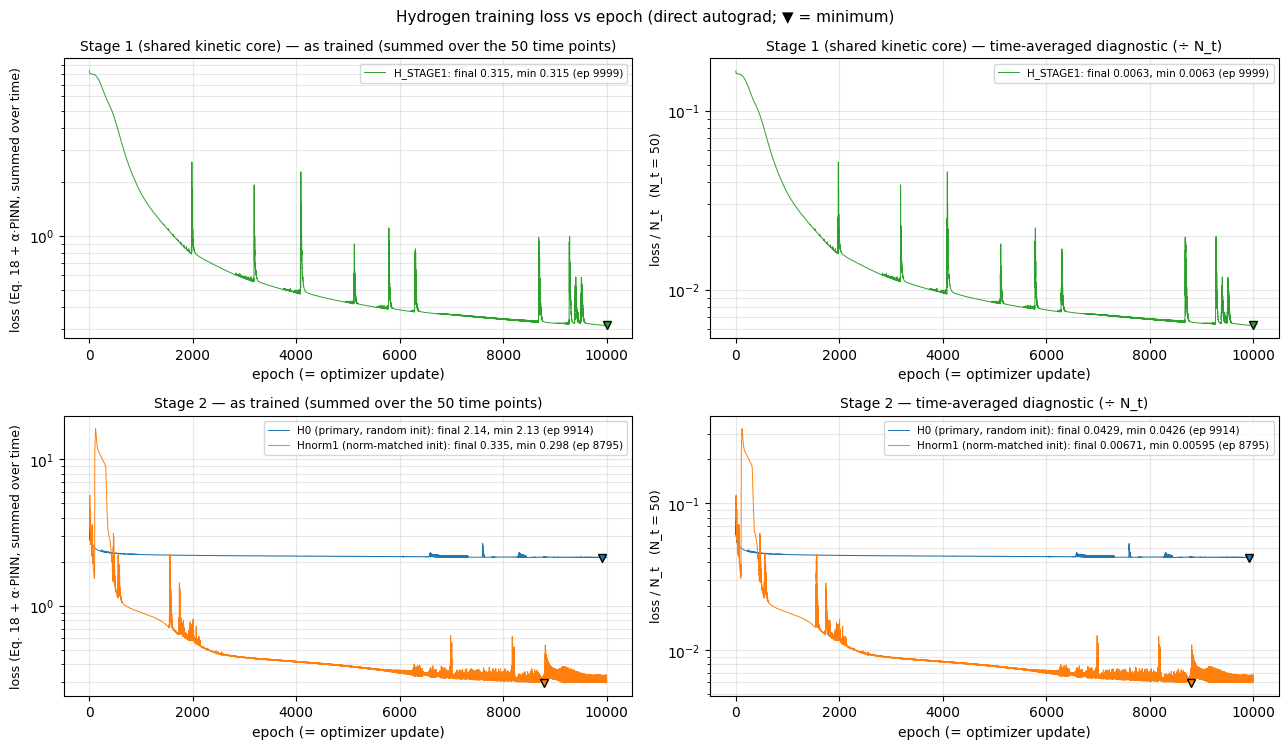

,stage,run,epochs,first,final,minimum,min_epoch,final_over_N_t
0,Stage 1 (shared kinetic core),H_STAGE1,10000,8.3228,0.3149,0.3149,9999,0.0063
1,Stage 2,"H0 (primary, random init)",10000,3.3243,2.1431,2.1293,9914,0.0429
2,Stage 2,Hnorm1 (norm-matched init),10000,5.6161,0.3355,0.2976,8795,0.0067


In [4]:
import pandas as pd

n_t = len(np.load(ROOT / "chemkan/data/generated/hydrogen.npz")["t"])      # 50 time points
# directory of the Stage-1 checkpoint both Stage-2 runs loaded
stage1_dir = (ROOT / _json.loads((RUN_DIR / "config.json").read_text())["stage1_from"]["path"]).parent
rows = [("Stage 1 (shared kinetic core)",
         [("H_STAGE1", stage1_dir / "history_stage1.csv", "tab:green")]),
        ("Stage 2",
         [("H0 (primary, random init)", RUN_DIR / "history_stage2.csv", "tab:blue"),
          ("Hnorm1 (norm-matched init)", COMPARE_DIR / "history_stage2.csv", "tab:orange")])]

fig, axes = plt.subplots(2, 2, figsize=(13, 7.6))
summary = []
for r, (stage, runs) in enumerate(rows):
    for c, (divisor, ylabel) in enumerate(((1, "loss (Eq. 18 + α·PINN, summed over time)"),
                                           (n_t, f"loss / N_t   (N_t = {n_t})"))):
        ax = axes[r, c]
        for label, path, colour in runs:
            h = pd.read_csv(path)
            loss = h.total_loss / divisor
            k = int(loss.idxmin())
            ax.semilogy(h.epoch, loss, lw=0.7, color=colour,
                        label=f"{label}: final {loss.iloc[-1]:.3g}, min {loss[k]:.3g} (ep {k})")
            ax.plot(h.epoch[k], loss[k], "v", color=colour, mec="k", ms=6)
            if c == 0:
                summary.append(dict(stage=stage, run=label, epochs=len(h),
                                    first=h.total_loss.iloc[0], final=h.total_loss.iloc[-1],
                                    minimum=h.total_loss.min(), min_epoch=k,
                                    final_over_N_t=h.total_loss.iloc[-1] / n_t))
        ax.set_xlabel("epoch (= optimizer update)")
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(alpha=.3, which="both")
        ax.legend(fontsize=7.5, loc="upper right")
        ax.set_title(f"{stage} — " + ("as trained (summed over the 50 time points)" if c == 0
                                      else "time-averaged diagnostic (÷ N_t)"), fontsize=10)
fig.suptitle("Hydrogen training loss vs epoch (direct autograd; ▼ = minimum)", fontsize=11)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"hydrogen_training_loss_comparison.{ext}", dpi=200, bbox_inches="tight")
plt.show()
display(pd.DataFrame(summary).round(4))

### Figure 7 — trajectories and losses at the two published conditions

Left (A–C): training condition φ=0.9, T₀=1050 K. Right (D–F): held-out condition
φ=1.3, T₀=1150 K. Dots are the stored Cantera reference at 50 observation times;
solid curves are closed-loop predictions on a 601-point display grid.

The first two figures are **paper-style**: each species is multiplied by the factor printed
in the paper's Fig. 7 (H₂, O₂, O, OH ×10², H₂O ×10¹; H₂O₂ ×10⁶, HO₂ ×10⁴, H ×10⁴). The
paper's drawn O₂ and H curves match ×10¹ and ×10³, so here those two curves sit 10× higher
than in the paper and stretch their panels; the legend and footnote say so.

The **true-scale companion** below them plots species at their **true mass fraction**, with
no display multipliers. Temperature is linear in kelvin and shares one range across
conditions and models. The species rows use a **symlog** y axis, linear within ±10⁻⁶ (shaded) and logarithmic
outside it: several predicted mass fractions go **negative** at the held-out condition,
and a log axis would silently drop exactly those points. Species colours follow the
supplied paper figure.

Each panel reports normalized trajectory loss for its displayed state(s): squared
train-min-max-normalized errors summed over the **50 observation times**, then averaged
over the states in that panel. The column title gives the full ten-state mean (including
N₂). Per-species losses are saved to `fig07_hydrogen_per_state_mse.csv`. Sparse reference
sampling can miss the height of a sharp radical peak; the dense curve does not create
extra reference data.

Files: `fig07_hydrogen_trajectories_<model>.png` (paper-style) and
`fig07_hydrogen_trajectories_<model>_true_scale.png`.

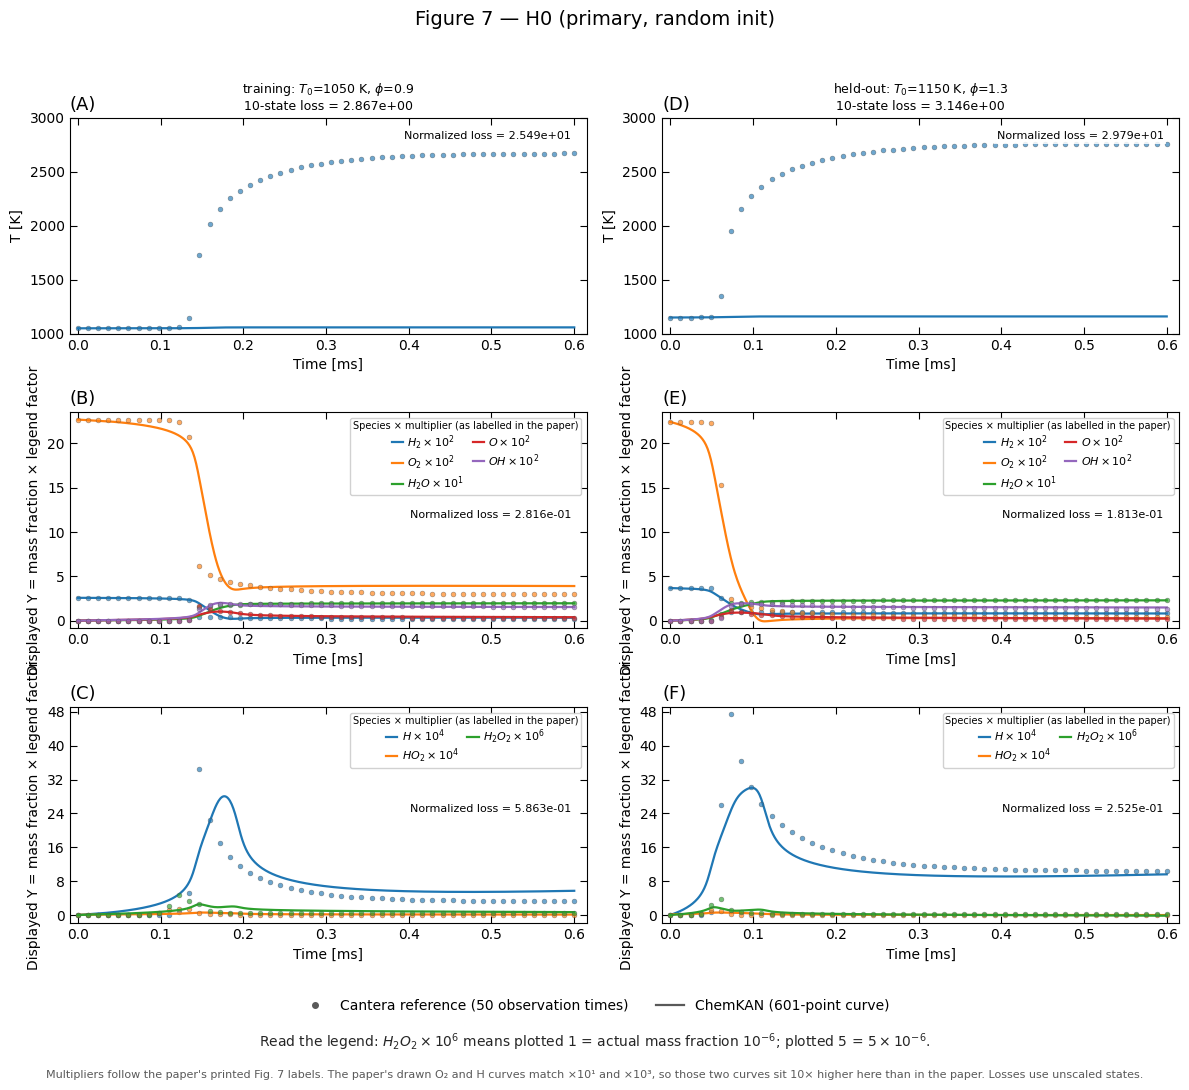

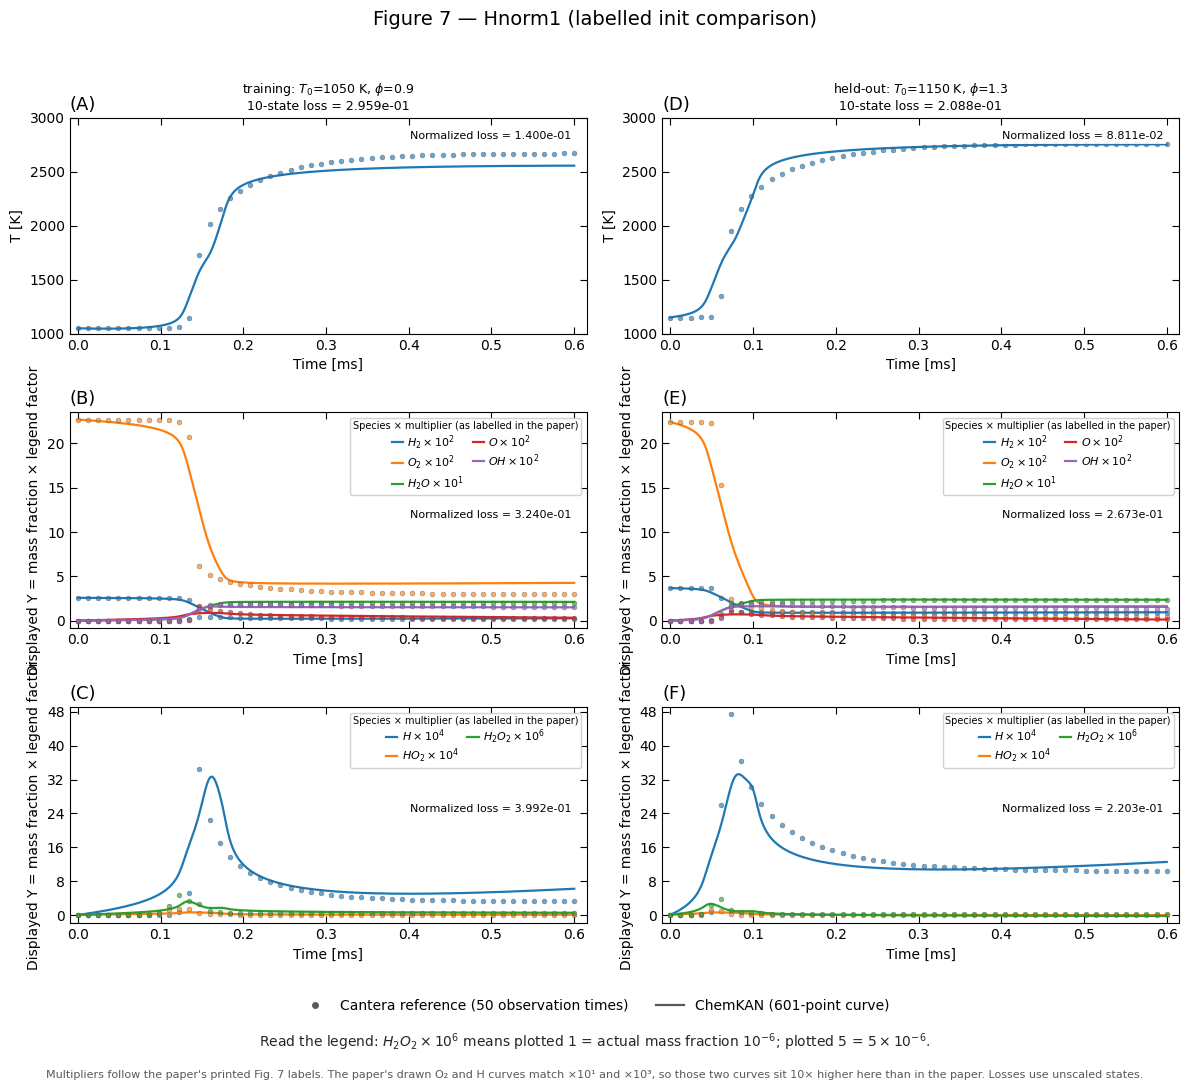

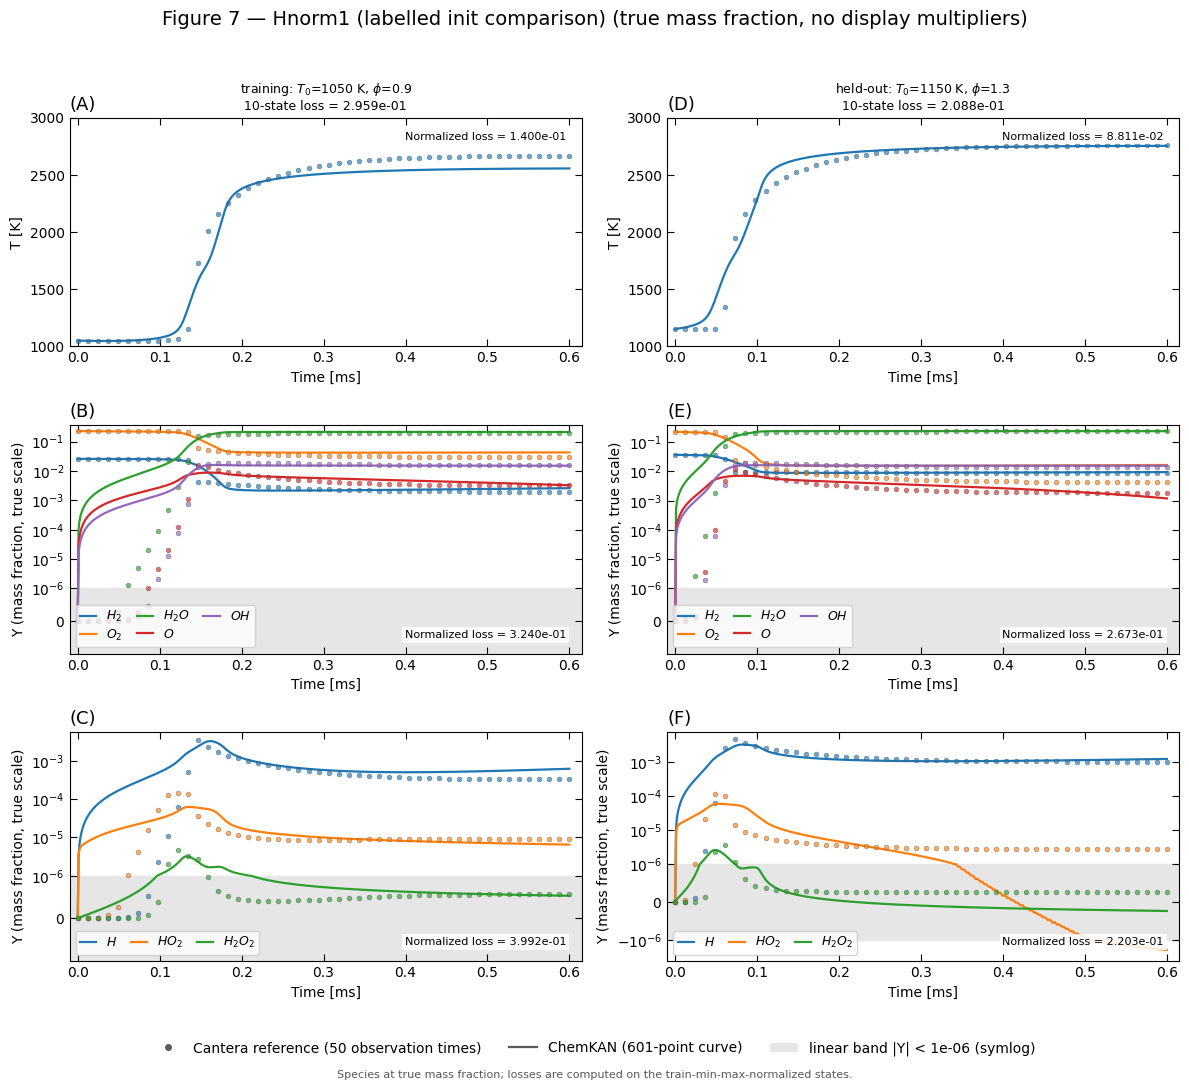

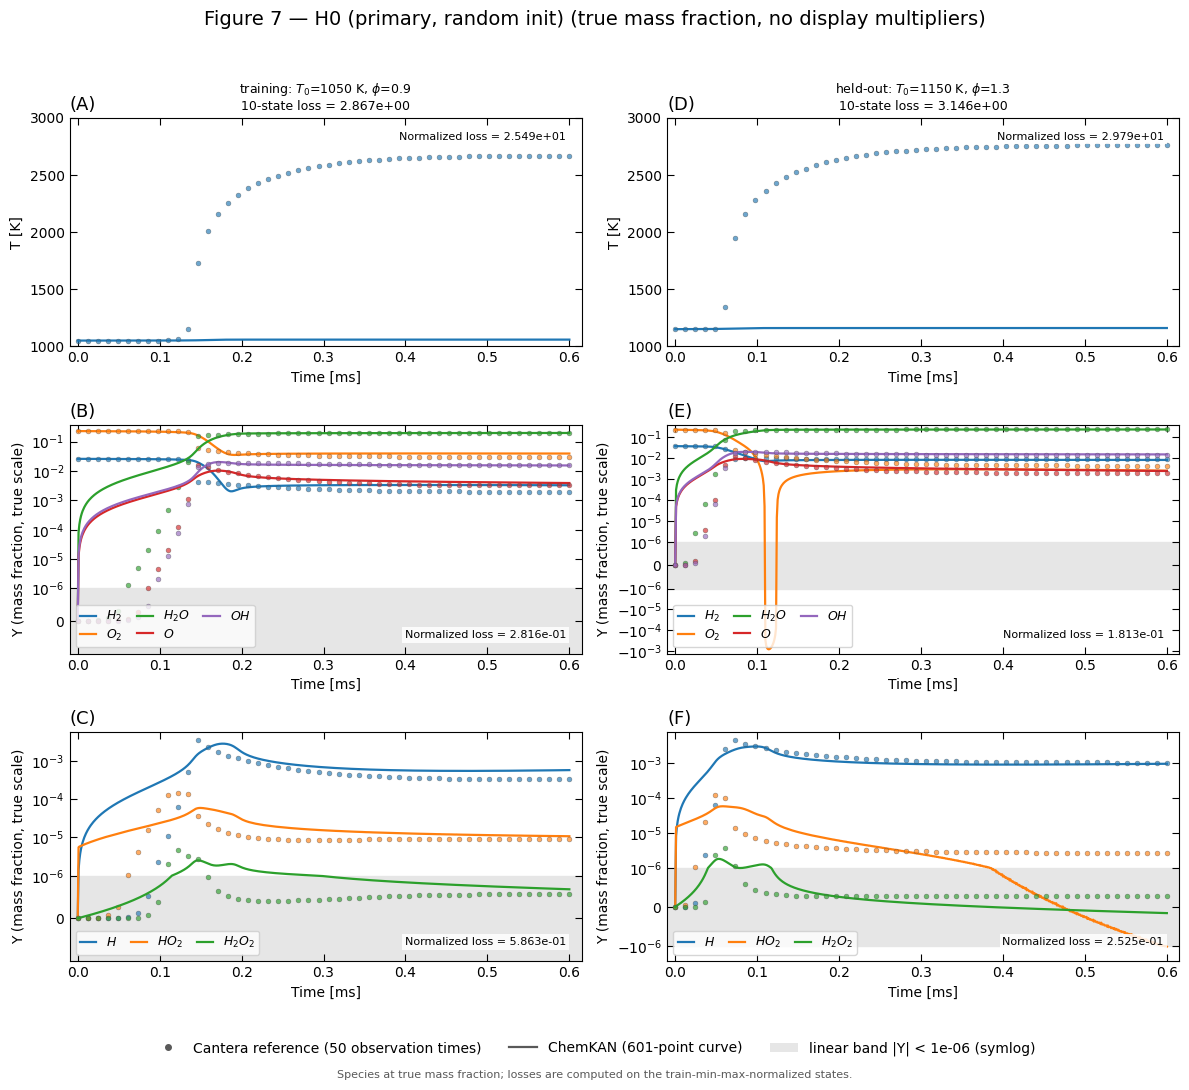

,model,condition,role,case_Eq18_MSE,T_MSE,H2_MSE,H_MSE,O_MSE,O2_MSE,OH_MSE,H2O_MSE,HO2_MSE,H2O2_MSE,N2_MSE
0,"H0 (primary, random init)",1050/0.9,training,2.866599,25.494375,0.188361,0.192140,0.428566,0.283107,0.232325,0.275718,1.298385,0.268312,0.004704
1,"H0 (primary, random init)",1150/1.3,held-out,3.146122,29.787168,0.088151,0.215534,0.171768,0.114488,0.375356,0.156804,0.446988,0.095008,0.009954
2,Hnorm1 (labelled init comparison),1050/0.9,training,0.295947,0.140029,0.088256,0.158124,0.592539,0.215837,0.450126,0.273347,0.918562,0.120945,0.001703
3,Hnorm1 (labelled init comparison),1150/1.3,held-out,0.208795,0.088106,0.108828,0.157577,0.275742,0.253675,0.501105,0.197263,0.390291,0.112952,0.002408


Predicted mass fractions that go negative:
  H0 (primary, random init)              T0=1150 K phi=1.3: O2, HO2, H2O2
  Hnorm1 (labelled init comparison)      T0=1150 K phi=1.3: HO2, H2O2


In [5]:
# Figure code: chemkan/scripts/figures/fig07_hydrogen_trajectories.py
import pandas as pd

from fig07_hydrogen_trajectories import CONDITIONS, make_true_scale_figure
from fig07_hydrogen_trajectories import make_figure as make_fig07

# Re-exported for the diagnostic cells further down, so the conditions and the dense grid
# have one definition (the figure script's).
CONDS = CONDITIONS

# Evaluates both models once, writes the per-state loss table and saves the figures.
# Paper-style Figure 7 first (the paper's printed display multipliers), one per model.
multiplier_figs, fig07_results = make_fig07(
    run_dirs={label: directory for label, (_stem, directory) in SETS.items()},
    output_dir=FIG_DIR, table_path=TABLE_DIR / "fig07_hydrogen_per_state_mse.csv")
for fig in multiplier_figs.values():
    display(fig)
    plt.close(fig)
t_d = fig07_results["t_dense"]

_, fig07_true_scale = make_true_scale_figure(precomputed=fig07_results, output_dir=FIG_DIR,
                                             show=True)

display(pd.DataFrame(fig07_results["rows"]).drop(columns="checkpoint"))
print("Predicted mass fractions that go negative:")
for (label, T0, phi), bad in sorted(fig07_true_scale["negatives"].items()):
    print(f"  {label:38s} T0={T0:.0f} K phi={phi}: {', '.join(bad)}")
if not fig07_true_scale["negatives"]:
    print("  none")

### Figure 8A — paper-scale view and full-range comparison

The first pair of heatmaps uses **0–10 ×10⁻⁴**, matching the paper's displayed numerical
range. As in the paper, **smaller MSE is lighter**. Navy crosses mark
35 training conditions and a teal dot marks the held-out case; 405 additional grid
points are unseen. Both models share the same normalization, limits and colours.

The upper colour-bar extension means **greater than 10⁻³**, not equal to 10⁻³.
Every saved error is above this bound for both runs, so the first view saturates at the
dark end. The second pair uses the full measured range, **0–4**, in the same Eq. 18 units
with **no ×10⁻⁴ factor**: 4 is the first round tick above the largest error, 3.69 (Hnorm1
near 975 K). It keeps the light-for-small convention and shows the spatial differences.
The table gives actual minima, medians, maxima and overflow counts. No error values are changed or divided to fit the paper.

Our loss is Eq. 18: the squared normalized-state error averaged over the state variables
and summed over the time points, with no 1/N_t factor. The 21×21 grid is reconstructed from its count and
spacing; normalization always uses the original training statistics.

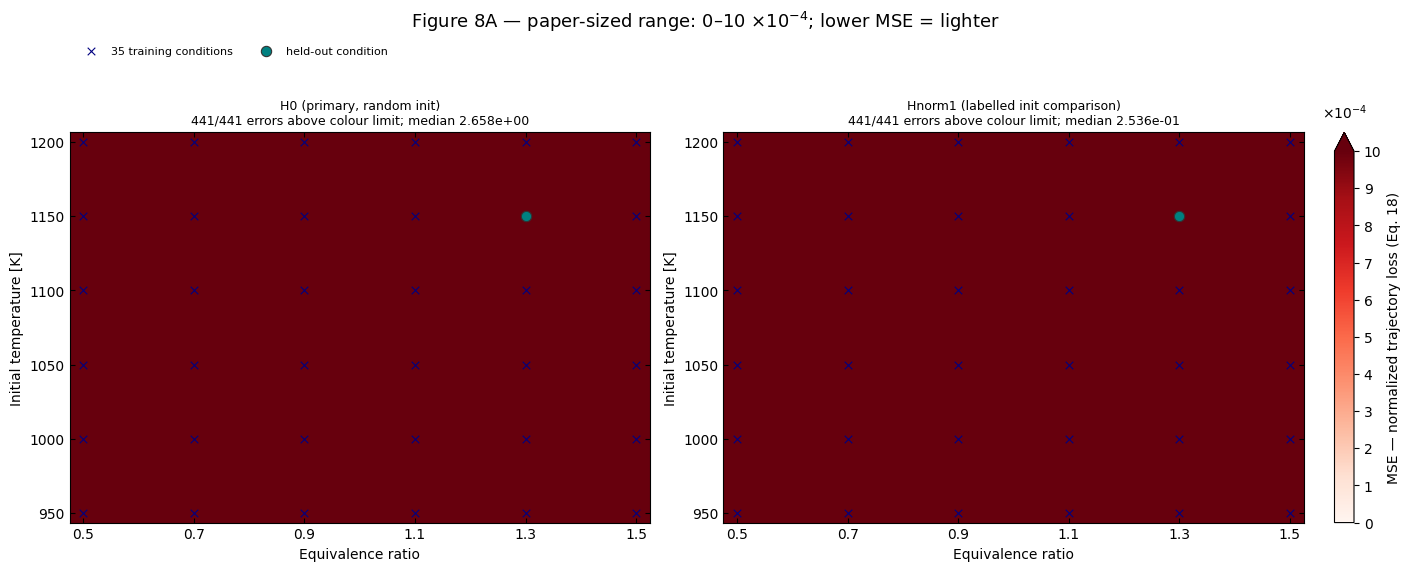

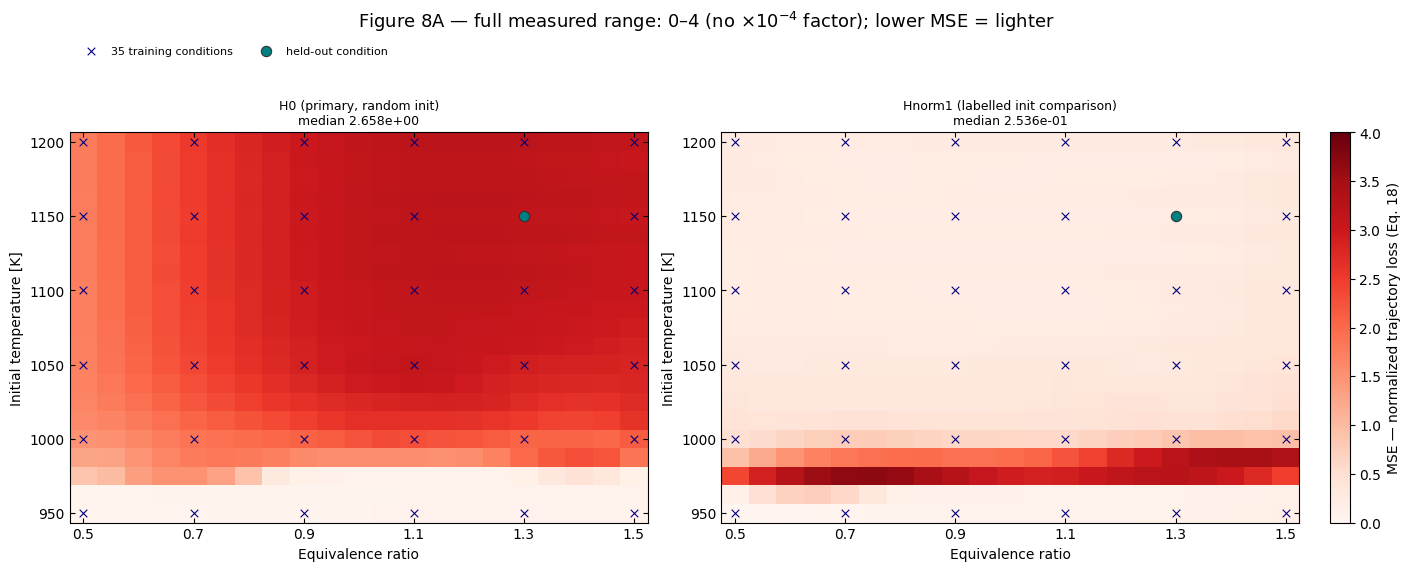

,model,minimum,median,maximum,above_paper_scale,evaluated,paper_scale_max
0,"H0 (primary, random init)",0.031972,2.657622,3.222625,441,441,0.001
1,Hnorm1 (labelled init comparison),0.012698,0.253554,3.691566,441,441,0.001


In [6]:
# Figure code: chemkan/scripts/figures/fig08_hydrogen_generalization.py
import pandas as pd

from fig08_hydrogen_generalization import make_figure as make_fig08a

_, fig08a_results = make_fig08a(
    table_paths={label: GEN / f"{stem}_generalization_441.csv"
                 for label, (stem, _d) in SETS.items()},
    output_dir=FIG_DIR, show=True)

display(pd.DataFrame(fig08a_results["scale_rows"]))

### Figure 8A — time-averaged diagnostic

The same losses divided by `N_t`, the number of time points each Eq. 18 loss sums over
(50 on the 441-condition grid). This is a derived diagnostic, not the paper's Eq. 18 loss.
The full-range view runs **0–0.075**: the same data as the 0–4 view above, divided by 50.
The paper-scale view keeps the paper's 0–10 ×10⁻⁴ range.

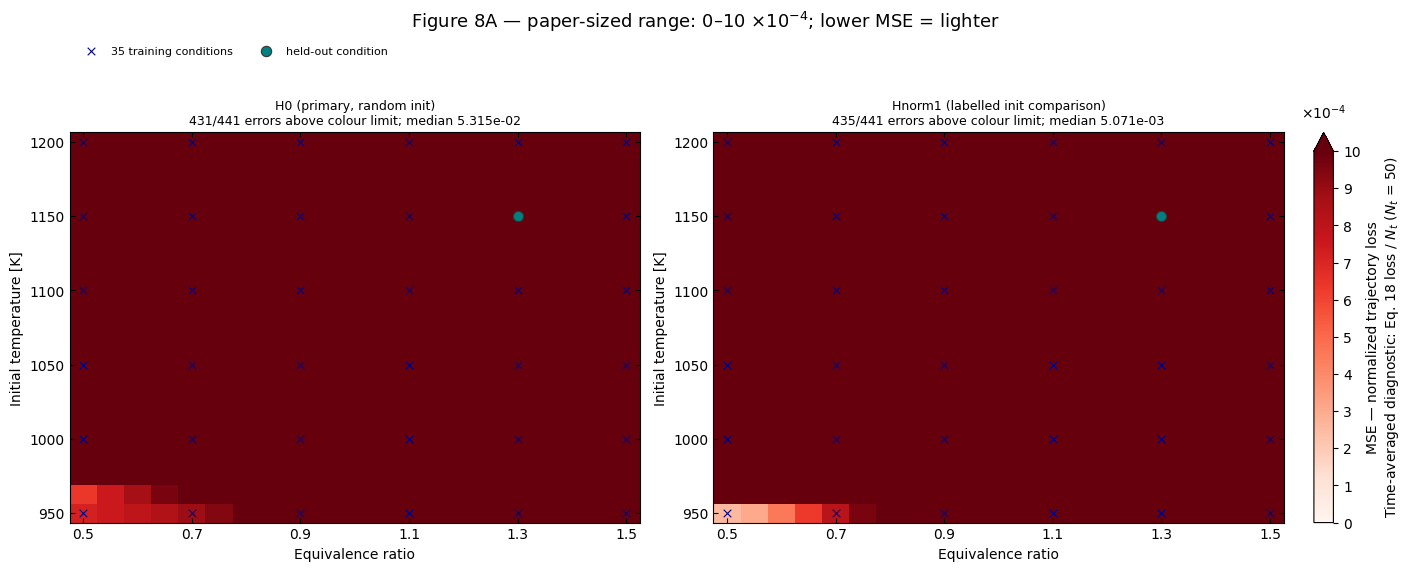

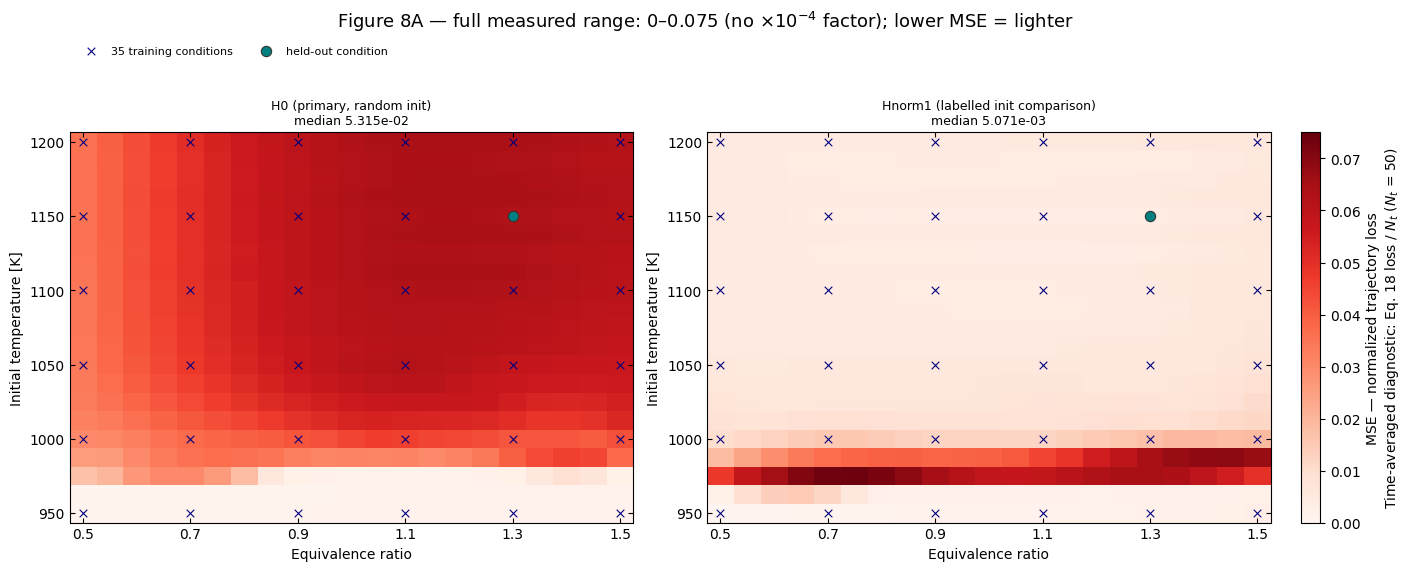

reduction: Time-averaged diagnostic: Eq. 18 loss / $N_t$ ($N_t$ = 50)
  H0 (primary, random init)            median Eq. 18 loss / N_t = 5.315e-02
  Hnorm1 (labelled init comparison)    median Eq. 18 loss / N_t = 5.071e-03


In [7]:
from fig08_hydrogen_generalization import make_figure as make_fig08a

_, fig08a_time_averaged = make_fig08a(
    table_paths={label: GEN / f"{stem}_generalization_441.csv"
                 for label, (stem, _d) in SETS.items()},
    output_dir=FIG_DIR, time_averaged=True, show=True)

n_times = fig08a_time_averaged["n_times"]
print("reduction:", fig08a_time_averaged["reduction"])
for row in fig08a_time_averaged["scale_rows"]:
    print(f"  {row['model']:36} median Eq. 18 loss / N_t = {row['median'] / n_times:.3e}")

### Figure 8B — ignition delay

Ignition delay = **time of maximum dT/dt**, the paper's definition (Sec. III B), applied
with **no minimum-rise threshold** — so a delay is reported for every evaluated condition,
including a flat prediction whose derivative peaks on numerical noise. Reference and model
are put on the **same** dense 601-point grid over 0–0.6 ms and through the **same**
estimator, so a coarse 50-point reference derivative is never compared against a dense
model derivative.

The evaluated set is the paper's own: the 30 conditions that ignite in the window, i.e.
`T0` = 1000–1200 K across the six equivalence ratios; the paper states the lowest-temperature
cases do not ignite, and the stored reference agrees (the six 950 K cases rise by exactly
0.0 K). It is written out explicitly, never derived from a threshold, and never depends on
whether the model succeeds.

**Read the delay with the temperature rise.** Every marker is plotted, so H0's delays track
the reference closely while its median temperature rise is 9 K against the reference's
1581 K. The panel titles and the printout below carry that number for exactly this reason:
on delay alone the failed model would outrank Hnorm1 (3.4 % vs 28.9 % median error).


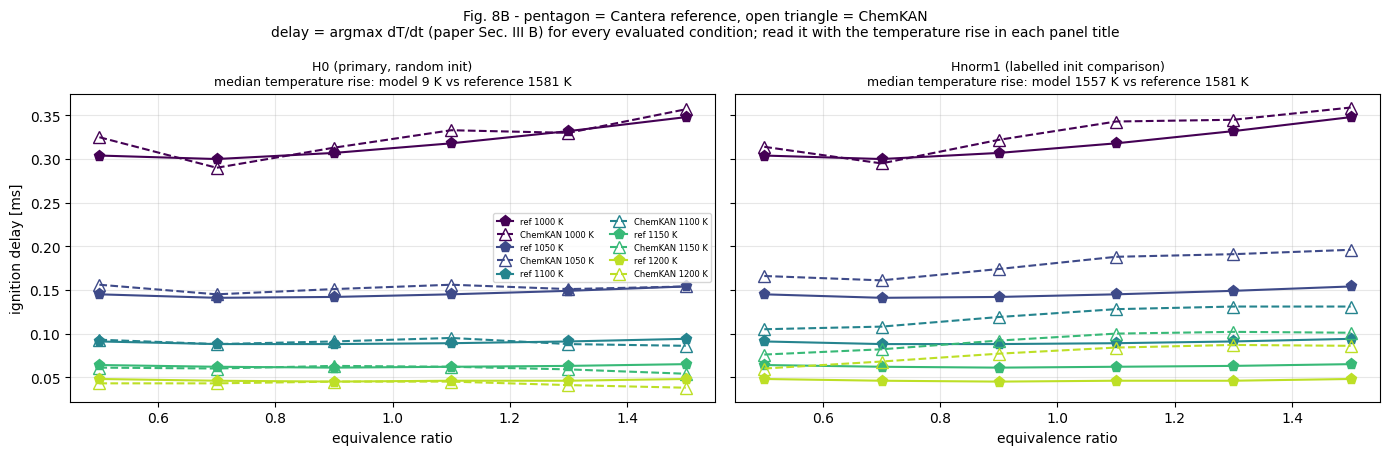

H0 (primary, random init): 30 evaluated conditions (the paper's set) | statuses {'evaluated': 30}
    |relative delay error|: median 3.4%  max 20.8%
    median temperature rise: model 9 K vs reference 1581 K
Hnorm1 (labelled init comparison): 30 evaluated conditions (the paper's set) | statuses {'evaluated': 30}
    |relative delay error|: median 28.9%  max 89.1%
    median temperature rise: model 1557 K vs reference 1581 K


In [8]:
# Figure code: chemkan/scripts/figures/fig08_hydrogen_ignition.py
from fig08_hydrogen_ignition import make_figure as make_fig08b

_, fig08b_results = make_fig08b(
    table_paths={label: TABLE_DIR / f"hydrogen_ignition_delay_{stem}.csv"
                 for label, (stem, _d) in SETS.items()},
    output_path=FIG_DIR / "fig08b_hydrogen_ignition_delay", show=True)

for label, summary in fig08b_results.items():
    print(f"{label}: {summary['conditions']} evaluated conditions (the paper's set) | "
          f"statuses {summary['statuses']}")
    if summary["median_relative_error"] is not None:
        # Always read together: a small delay error on a flat trajectory is not an
        # ignition, and the temperature rise is what says so. No threshold is applied.
        print(f"    |relative delay error|: median {summary['median_relative_error']:.1%}  "
              f"max {summary['max_relative_error']:.1%}")
        print(f"    median temperature rise: model "
              f"{summary['median_model_temperature_rise_K']:.0f} K vs reference "
              f"{summary['median_reference_temperature_rise_K']:.0f} K")

### Table I — networks, parameters, species, and a *local* efficiency measurement

The paper's ChemNODE and ChemKAN speed-ups are literature values measured against
Arrhenius.jl on other hardware with an unstated timing scope. Our number is a **local
PyTorch-vs-Cantera benchmark** over the same task (36 initial conditions, 50 output times,
0–0.6 ms). The two are reported side by side and must not be merged.

Accuracy is reported *with* the timing, because a model that does not reproduce the
dynamics is fast for the wrong reason.

In [9]:
bench = {}
for label, (stem, d) in SETS.items():
    bench[label] = _json.loads(
        (TABLE_DIR / f"hydrogen_inference_benchmark_{stem}.json").read_text())

table = [
    dict(model="ChemNODE (Ref. 17)", networks=7, parameters=637,
         species="H2,O2,H2O,N2,O,OH + T", speedup="2.3x", source="paper_reported"),
    dict(model="ChemKAN (paper)", networks=1, parameters=344,
         species="9 species + T", speedup="2.0x", source="paper_reported"),
]
for label, b in bench.items():
    ok = next(r for r in b["cantera"]["runs"] if r.get("status") == "ok")
    acc = b["accuracy"]
    table.append(dict(
        model=f"ChemKAN ({label})", networks=1, parameters=b["parameter_count"],
        species=f"{len(species)} species + T",
        speedup=f"{ok['speedup_vs_chemkan']:.2f}x", source="local_measured"))
    print(f"{label}")
    print(f"   ChemKAN {b['chemkan']['median_s']:.3f} s vs Cantera {ok['median_s']:.3f} s "
          f"(rtol={ok['rtol']:g}, atol={ok['atol']:g})  ->  {ok['speedup_vs_chemkan']:.2f}x")
    # Continuous accuracy only -- no ignited/not count. Rises are max(T) - T0.
    ps = acc["temperature_diagnostics"]["paper_fig8b_set_T0_1000_1200K"]
    lo = acc["temperature_diagnostics"]["T0_950K"]
    print(f"   paper's 30 conditions: median temperature rise model "
          f"{ps['model_temperature_rise_K']['median']:.0f} K vs reference "
          f"{ps['reference_temperature_rise_K']['median']:.0f} K; 950 K row: model rise up to "
          f"{lo['model_temperature_rise_K']['max']:.0f} K (reference "
          f"{lo['reference_temperature_rise_K']['max']:.0f} K); "
          f"median peak-T error {acc['peak_temperature_abs_error_K']['median']:.1f} K")
    for r in b["cantera"]["runs"]:
        if r.get("status") != "ok":
            print(f"   Cantera at rtol={r['rtol']:g} atol={r['atol']:g}: {r['status']}")
    print(f"   hardware: {b['hardware']['machine']}, torch {b['chemkan']['torch']}, "
          f"{b['chemkan']['threads']} threads, {b['warmup']} warm-up + {b['repetitions']} reps")

if SAVE_TABLES:
    f = TABLE_DIR / "hydrogen_efficiency.csv"
    with f.open("w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(table[0])); w.writeheader(); w.writerows(table)
    print("\nsaved", f)

H0 (primary, random init)
   ChemKAN 1.871 s vs Cantera 0.271 s (rtol=1e-09, atol=1e-15)  ->  0.14x
   paper's 30 conditions: median temperature rise model 9 K vs reference 1581 K; 950 K row: model rise up to 0 K (reference 0 K); median peak-T error 1546.5 K
   Cantera at rtol=1e-06 atol=1e-08: integration_failed: CanteraError
   hardware: arm64, torch 2.13.0, 4 threads, 2 warm-up + 5 reps
Hnorm1 (labelled init comparison)
   ChemKAN 0.470 s vs Cantera 0.236 s (rtol=1e-09, atol=1e-15)  ->  0.50x
   paper's 30 conditions: median temperature rise model 1557 K vs reference 1581 K; 950 K row: model rise up to 189 K (reference 0 K); median peak-T error 38.1 K
   Cantera at rtol=1e-06 atol=1e-08: integration_failed: CanteraError
   hardware: arm64, torch 2.13.0, 4 threads, 2 warm-up + 5 reps

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/hydrogen_efficiency.csv


**Table I outcome.** Both local measurements are **slower** than Cantera (0.14× for
`H0`, 0.50× for `Hnorm1`), not the paper's 2.0× speed-up. The comparison is not
like-for-like — different reference implementation, hardware and timing scope — so this
neither confirms nor refutes the paper's number; it is our own measurement, reported as
such. Cantera could not integrate at the model's own tolerances (rtol 1e-6, atol 1e-8) and
that is recorded per tolerance setting rather than hidden.

Note also that `H0` is *slower* than `Hnorm1` despite a median temperature rise of only 9 K: a badly conditioned
right-hand side can force small solver steps without producing any physical ignition.

---

## Section III B — status against the paper

| paper result | our result | status | remaining difference |
|---|---|---|---|
| Fig. 7 temperature + species at both published conditions | `H0` rises 9 K and 10 K at the two conditions; `Hnorm1` reproduces the rise | **not matched** (`H0`) | the primary run's Stage-2 temperature stays essentially flat |
| Fig. 8A 441-condition errors | all 441 evaluated per condition, 0 integration failures | **evaluated, not matched** | `H0` median MSE 2.66; `Hnorm1` 0.254 |
| Fig. 8A ≈10⁻⁴ at the 1000 K training conditions | our per-condition MSEs are order 10⁻¹–10⁰ | **not matched** | same absolute-error gap as biodiesel |
| Fig. 8B ignition delay over 30 conditions | median temperature rise `H0` **9 K**, `Hnorm1` **1557 K**, reference 1581 K; `Hnorm1` median delay error 28.9 % | **not matched** (`H0`), **partially matched** (`Hnorm1`) | `H0`'s 3.4 % median delay error describes a flat curve; at the 950 K row `Hnorm1` rises up to 189 K where the reference rises 0.0 K |
| Table I: 1 network, 344 parameters, 9 species + T | 1 network, 344 measured, 9 species + T | **matched** | — |
| Table I: 2.0× speed-up | 0.14× (`H0`), 0.50× (`Hnorm1`), local PyTorch-vs-Cantera | **not matched** | different reference implementation, hardware and timing scope |

**What this establishes.** The N=4/base-ON reading does not remove the Stage-2
heat-release failure. A single norm-matched initialization (`Hnorm1`) does recover
ignition-scale heating across the paper's 30 conditions (median rise 1557 K vs 1581 K), which sharpens the evidence that the thermodynamic
pathway's initialization is strongly implicated — but it is **one** initialization, not a
seed study, and it does not establish a root cause. The detailed failure and initialization
diagnostics remain in Notebook 09; this notebook does not duplicate them.

## Base-OFF versus base-ON — saved initialization comparisons

Compare the historical **N=5/base-OFF** architecture against **N=4/base-ON**, at the
same 344-parameter count, separately for default random and norm-matched direction-1
thermodynamic initialization. Both use direct autograd and 10,000 Stage-2 epochs.
These are separately trained architectures with their own Stage-1 checkpoints;
this is **not** a base-activation toggle on identical learned weights, nor an FSA comparison.
The norm-matched pair uses identical recorded initial thermodynamic Linear vectors.

The curves show temperature at the two Figure-7 conditions. The tables include full
train/test losses and condition-specific total, temperature and species losses. All losses
use the existing train-only normalization and sum over the 50 observation times;
curves use 601 display times. No training occurs. The historical default-random row is
the control specified for the first proposed FSA experiment.


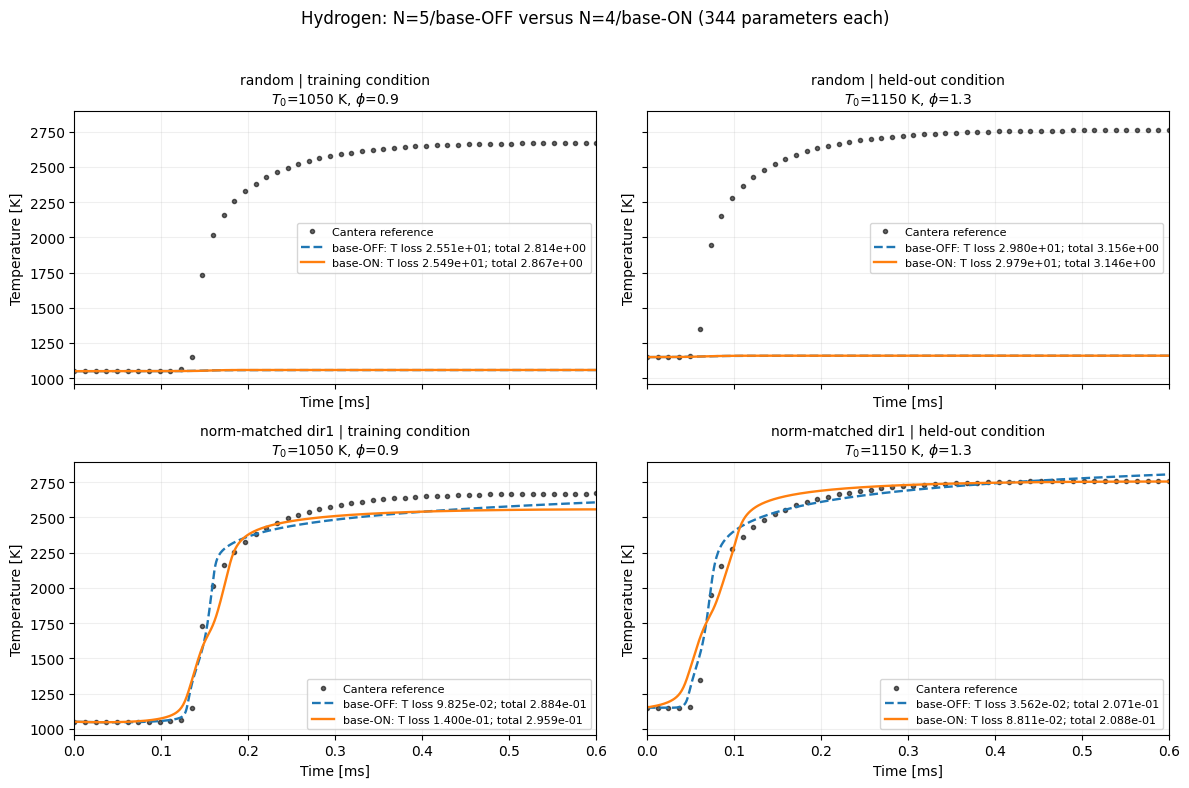

,initialization,architecture,num_basis,parameters,train_MSE,held_out_MSE
0,random,base-OFF,5,344,2.122741,3.155575
1,random,base-ON,4,344,2.139383,3.146122
2,norm-matched dir1,base-OFF,5,344,0.269726,0.207083
3,norm-matched dir1,base-ON,4,344,0.310101,0.208795


,initialization,architecture,condition,role,trajectory_MSE,temperature_MSE,species_mean_MSE,peak_temperature_K
0,random,base-OFF,1050 K / phi=0.9,training condition,2.814424,25.510193,0.292672,1058.007690
1,random,base-OFF,1150 K / phi=1.3,held-out condition,3.155575,29.800449,0.195034,1159.597900
2,random,base-ON,1050 K / phi=0.9,training condition,2.866599,25.494375,0.352402,1058.504761
3,random,base-ON,1150 K / phi=1.3,held-out condition,3.146122,29.787168,0.186006,1159.913330
4,norm-matched dir1,base-OFF,1050 K / phi=0.9,training condition,0.288421,0.098253,0.309551,2606.853027
5,norm-matched dir1,base-OFF,1150 K / phi=1.3,held-out condition,0.207083,0.035625,0.226134,2804.952148
6,norm-matched dir1,base-ON,1050 K / phi=0.9,training condition,0.295947,0.140029,0.313271,2556.883545
7,norm-matched dir1,base-ON,1150 K / phi=1.3,held-out condition,0.208795,0.088106,0.222205,2754.465088


Verified four saved runs and identical norm-matched initial Linear vectors. Source paths are in hydrogen_base_off_vs_on_runs.csv.


In [10]:
import json
import pandas as pd

base_compare_root = ROOT / "results/reproduction/chemkan/hydrogen/diagnostics"
base_compare_runs = [
    ("random", "base-OFF", "thermo_init_random_stage2_10000_seed0"),
    ("random", "base-ON", "base_on_n4/random_stage2_10000_seed0"),
    ("norm-matched dir1", "base-OFF", "thermo_init_scaled_random_normmatched_dir1_stage2_10000"),
    ("norm-matched dir1", "base-ON", "base_on_n4/normmatched_dir1_stage2_10000"),
]
base_compare_conditions = [(1050., .9, "training condition"), (1150., 1.3, "held-out condition")]
base_compare_times = np.linspace(float(t[0]), float(t[-1]), 601)
base_compare_summary, base_compare_losses, base_compare_init = [], [], []
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for init, architecture, relative in base_compare_runs:
    directory = base_compare_root / relative
    config = json.loads((directory / "config.json").read_text())
    metrics = json.loads((directory / "metrics.json").read_text())
    checkpoint = torch.load(directory / "checkpoint_final.pt", map_location="cpu", weights_only=False)
    comparison_model = build_chemkan(checkpoint, len(species), "cpu")
    comparison_solver = solver_from_ckpt(checkpoint)
    comparison_norm = load_input_scaling(checkpoint, "cpu")
    assert config["parameter_count"] == sum(p.numel() for p in comparison_model.parameters()) == 344
    assert config["architecture"]["num_basis"] == (5 if architecture == "base-OFF" else 4)
    assert config["architecture"]["use_base_act"] == (architecture == "base-ON")
    assert config["epochs"]["stage2"] == 10000 and config["sensitivity_backend"] == "direct_autograd"
    if init == "norm-matched dir1":
        base_compare_init.append(config["thermo_init"]["resulting_vector"])
    base_compare_summary.append(dict(initialization=init, architecture=architecture,
        num_basis=config["architecture"]["num_basis"], parameters=344,
        train_MSE=metrics["train_mse"], held_out_MSE=metrics["test_mse"],
        run=str(directory.relative_to(ROOT)), stage1_source=config["stage1_from"]["run_id"]))
    row = 0 if init == "random" else 1
    for col, (T0, phi, role) in enumerate(base_compare_conditions):
        indices = np.flatnonzero(np.isclose(ics[:, 0], T0) & np.isclose(ics[:, 1], phi))
        assert len(indices) == 1
        reference = states[int(indices[0])]
        initial = torch.as_tensor(reference[0], dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            curve = integrate_hydrogen(comparison_model, comparison_norm, comparison_solver,
                                       initial, base_compare_times)[:, 0].numpy()
            observations = integrate_hydrogen(comparison_model, comparison_norm, comparison_solver,
                                              initial, t)[:, 0]
            errors = (full_norm.normalize(observations) - full_norm.normalize(
                torch.as_tensor(reference, dtype=torch.float32))).square().sum(0).numpy()
        assert np.isfinite(curve).all() and np.isfinite(errors).all()
        if col == 1:
            assert np.isclose(errors.mean(), metrics["test_mse"], rtol=1e-4, atol=1e-6)
        base_compare_losses.append(dict(initialization=init, architecture=architecture,
            condition=f"{T0:g} K / phi={phi:g}", role=role,
            trajectory_MSE=float(errors.mean()), temperature_MSE=float(errors[-1]),
            species_mean_MSE=float(errors[:-1].mean()), peak_temperature_K=float(curve[:, -1].max()),
            temperature_rise_K=float(curve[:, -1].max()-curve[0, -1]),
            **{f"{sp}_MSE": float(errors[k]) for k, sp in enumerate(species)}))
        ax = axes[row, col]
        if architecture == "base-OFF":
            ax.plot(t * 1e3, reference[:, -1], "ko", ms=3, alpha=.6, label="Cantera reference")
        ax.plot(base_compare_times * 1e3, curve[:, -1],
                color="tab:blue" if architecture == "base-OFF" else "tab:orange",
                ls="--" if architecture == "base-OFF" else "-", lw=1.7,
                label=f"{architecture}: T loss {errors[-1]:.3e}; total {errors.mean():.3e}")
        ax.set_title(f"{init} | {role}\n$T_0$={T0:g} K, $\phi$={phi:g}", fontsize=10)
        ax.set_xlabel("Time [ms]"); ax.set_ylabel("Temperature [K]")
        ax.set_xticks(np.arange(0, .61, .1)); ax.set_xlim(0, .6)
        ax.legend(fontsize=8); ax.grid(alpha=.2)
assert base_compare_init[0] == base_compare_init[1]
fig.suptitle("Hydrogen: N=5/base-OFF versus N=4/base-ON (344 parameters each)")
fig.tight_layout(rect=(0, 0, 1, .96))
if SAVE_FIGURES:
    for extension in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"hydrogen_base_off_vs_on_comparison.{extension}", dpi=180, bbox_inches="tight")
plt.show()
base_comparison_summary = pd.DataFrame(base_compare_summary)
base_comparison_metrics = pd.DataFrame(base_compare_losses)
display(base_comparison_summary.drop(columns=["run", "stage1_source"]))
display(base_comparison_metrics.iloc[:, :8])
if SAVE_TABLES:
    base_comparison_summary.to_csv(TABLE_DIR / "hydrogen_base_off_vs_on_runs.csv", index=False)
    base_comparison_metrics.to_csv(TABLE_DIR / "hydrogen_base_off_vs_on_metrics.csv", index=False)
print("Verified four saved runs and identical norm-matched initial Linear vectors. Source paths are in hydrogen_base_off_vs_on_runs.csv.")


---
## Appendix — H0 failure diagnostics

The paper comparisons above are the main figures. This appendix keeps the failure
analysis for the primary H0 run: the recorded Stage-1/Stage-2 losses, the right-hand side
evaluated along the true trajectory for H0 and for Hnorm1, the reaction-extent check, and
the thermodynamic-coefficient evidence. It does not repeat Figure 7 or replace the
Hnorm1 comparison above. Further initialization studies are in Notebook 09.


In [11]:
for stage in (1, 2):
    # Stage 1 was trained once and shared: H0 branches from it and stores only Stage 2.
    f = (STAGE1_DIR if stage == 1 else RUN_DIR) / f"history_stage{stage}.csv"
    if not f.exists():
        print(f"stage {stage}: no history file")
        continue
    rows = list(csv.DictReader(f.open()))
    key = next((k for k in rows[0] if "total" in k.lower() and "loss" in k.lower()),
               next(k for k in rows[0] if "loss" in k.lower()))
    print(f"stage {stage}: {len(rows)} epochs | first {float(rows[0][key]):.4e}"
          f" | final {float(rows[-1][key]):.4e}   (column '{key}')")

stage 1: 10000 epochs | first 8.3228e+00 | final 3.1488e-01   (column 'total_loss')
stage 2: 10000 epochs | first 3.3243e+00 | final 2.1431e+00   (column 'total_loss')


In [12]:
# --- Failure-diagnosis setup: open-loop RHS + Stage-1 (observed T) helpers ---
from chemkan.dynamics import ChemKANDynamics, KineticDynamics
from chemkan.temperature import ObservedTemperature
from chemkan.solver import integrate

DIAG_CONDS = [(1050, 0.9, "training"), (1150, 1.3, "held-out")]
m = len(species)
full_dyn = ChemKANDynamics(model, input_normalizer=input_norm)     # physical [Y,T] -> d[Y,T]/dt

def _cond_index(T0, phi):
    return int(np.argmin(np.abs(ics[:, 0] - T0) + np.abs(ics[:, 1] - phi)))

def rhs_along_reference(ref):
    """Model d[Y,T]/dt evaluated on the EXACT reference states (open loop, no integration),
    and the finite-difference reference derivative. Both (Nt, m+1), physical units."""
    tf = torch.as_tensor(t, dtype=torch.float32)
    with torch.no_grad():
        md = torch.stack([full_dyn(tf[j], torch.as_tensor(ref[j], dtype=torch.float32).unsqueeze(0))[0]
                          for j in range(len(t))]).numpy()
    return md, np.gradient(ref, t, axis=0)

def stage1_species_observed_T(ref):
    """Integrate Stage 1 (species only) with THIS condition's true T(t) supplied."""
    obsT = ObservedTemperature(torch.as_tensor(t, dtype=torch.float32),
                               torch.as_tensor(ref[:, -1], dtype=torch.float32).reshape(-1, 1, 1))
    kin = KineticDynamics(model.kinetic, obsT, input_normalizer=input_norm)
    with torch.no_grad():
        return integrate(kin, torch.as_tensor(ref[0, :m], dtype=torch.float32).unsqueeze(0),
                         torch.as_tensor(t, dtype=torch.float32), solver)[:, 0].numpy()

def integrate_case(T0, phi, t_eval=None):
    """Closed-loop integration of one condition from its initial state alone.
    (Defined here since the ignition-gate cell that used to provide it was removed.)"""
    i = _cond_index(T0, phi)
    tt = t if t_eval is None else t_eval
    u0 = torch.as_tensor(states[i, 0], dtype=torch.get_default_dtype()).unsqueeze(0)
    pred = integrate_hydrogen(model, input_norm, solver, u0, tt)
    return i, states[i], pred[:, 0].numpy(), tt


def normstate(arr):
    """Full-state train-only min-max normalization, for comparable per-state errors."""
    return full_norm.normalize(torch.as_tensor(arr, dtype=torch.float32)).numpy()

print("diagnosis helpers ready | conditions:", DIAG_CONDS)


diagnosis helpers ready | conditions: [(1050, 0.9, 'training'), (1150, 1.3, 'held-out')]


saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/hydrogen_DIAGNOSTIC_rhs_along_truth.pdf


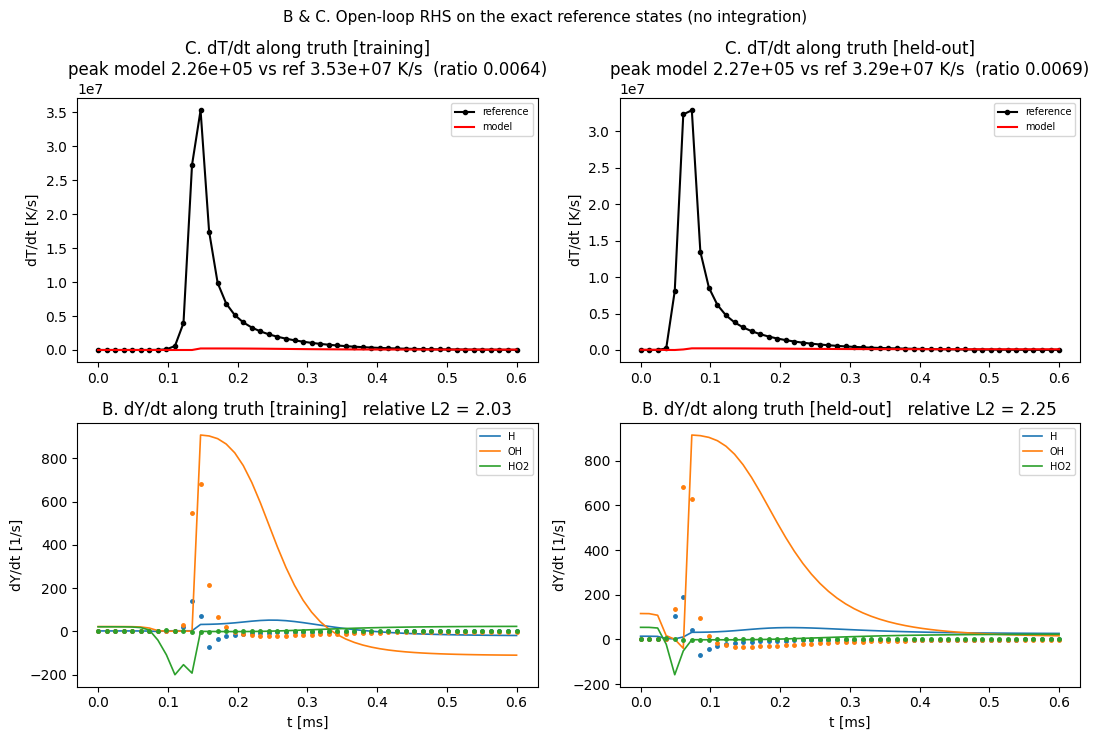

In [13]:
# B & C. Model right-hand side evaluated on the EXACT reference states (open loop).
fig, ax = plt.subplots(2, 2, figsize=(11, 7.5))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    md, rd = rhs_along_reference(ref)                       # model vs finite-diff reference dU/dt
    kmax = int(rd[:, -1].argmax())                          # reference peak-heat-release index
    ratio = md[kmax, -1] / rd[kmax, -1] if rd[kmax, -1] else float("nan")
    # C: temperature rate (heat release) -- the decisive test
    ax[0, c].plot(t * 1e3, rd[:, -1], "k-o", ms=3, label="reference")
    ax[0, c].plot(t * 1e3, md[:, -1], "r-", lw=1.5, label="model")
    ax[0, c].set_title(f"C. dT/dt along truth [{role}]\npeak model {md[kmax, -1]:.2e} vs ref "
                       f"{rd[kmax, -1]:.2e} K/s  (ratio {ratio:.4f})")
    ax[0, c].set_ylabel("dT/dt [K/s]"); ax[0, c].legend(fontsize=7)
    # B: species rates
    relL2 = np.linalg.norm(md[:, :m] - rd[:, :m]) / (np.linalg.norm(rd[:, :m]) + 1e-30)
    for sp in ["H", "OH", "HO2"]:
        k = species.index(sp)
        line, = ax[1, c].plot(t * 1e3, rd[:, k], "o", ms=2.5)
        ax[1, c].plot(t * 1e3, md[:, k], "-", lw=1.2, color=line.get_color(), label=sp)
    ax[1, c].set_title(f"B. dY/dt along truth [{role}]   relative L2 = {relL2:.2f}")
    ax[1, c].set_xlabel("t [ms]"); ax[1, c].set_ylabel("dY/dt [1/s]"); ax[1, c].legend(fontsize=7)
fig.suptitle("B & C. Open-loop RHS on the exact reference states (no integration)", fontsize=11)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"hydrogen_DIAGNOSTIC_rhs_along_truth.{ext}", dpi=300, bbox_inches="tight")
    print("saved", FIG_DIR / "hydrogen_DIAGNOSTIC_rhs_along_truth.pdf")
plt.show()


### The same open-loop check for Hnorm1

**Hnorm1** is the second Stage-2 run already used in the training-loss figure and the
initialization comparison above: same architecture (N = 4, base activation ON, 344
parameters), same shared Stage-1 kinetic core, same 10,000 Stage-2 epochs with direct
autograd. The **only** difference from H0 is the Stage-2 initialization of the
thermodynamic `Linear` layer — norm-matched, direction seed 1, instead of the default
random draw (`normmatched_dir1_stage2_10000`).

The cell repeats B & C for that model: the right-hand side evaluated on the **exact
reference states**, with no integration, at the same two conditions. Reading it against
the H0 panels above isolates what the initialization changed, because nothing else
differs between the two runs.


[training] Hnorm1 peak dT/dt 2.752e+07 vs reference 3.528e+07 K/s (78.0%) | species-rate relative L2 = 0.95
[held-out] Hnorm1 peak dT/dt 2.737e+07 vs reference 3.290e+07 K/s (83.2%) | species-rate relative L2 = 0.96


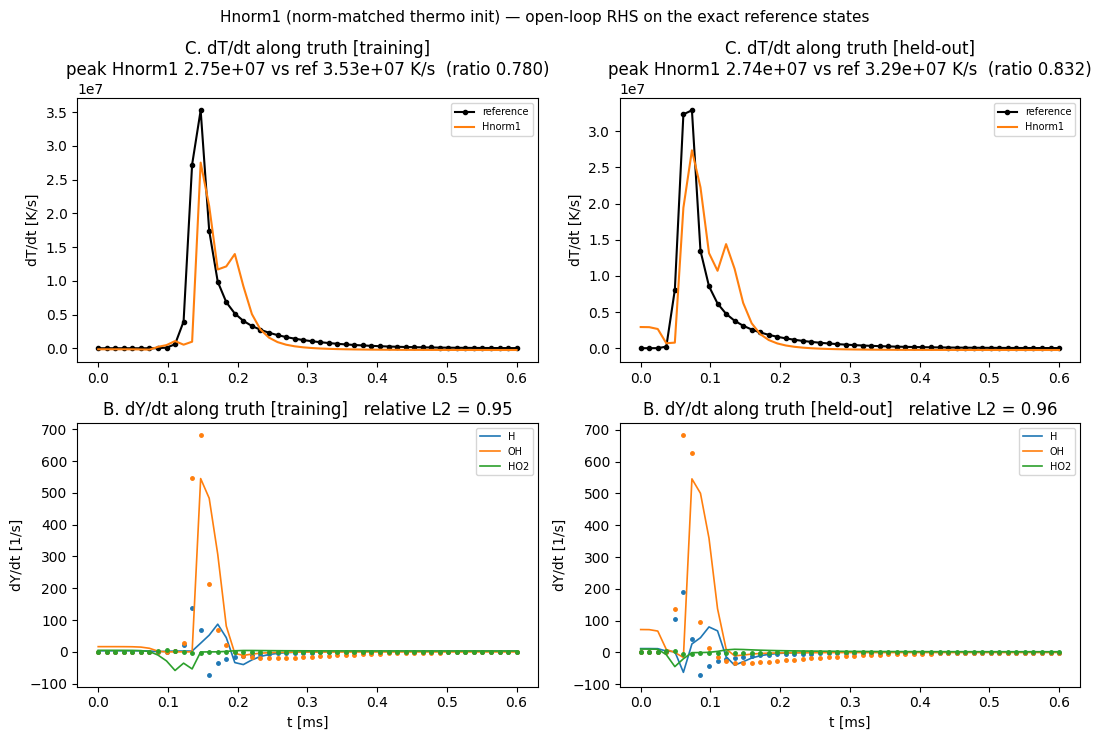

In [14]:
# B & C for Hnorm1: same open-loop RHS check, norm-matched thermo initialization.
ckpt_h1 = torch.load(COMPARE_DIR / "checkpoint_final.pt", map_location="cpu", weights_only=False)
model_h1 = build_chemkan(ckpt_h1, len(species), "cpu")
norm_h1 = load_input_scaling(ckpt_h1, "cpu")
dyn_h1 = ChemKANDynamics(model_h1, input_normalizer=norm_h1)

def rhs_along_reference_h1(ref):
    """Hnorm1 d[Y,T]/dt on the EXACT reference states, and the reference derivative."""
    tf = torch.as_tensor(t, dtype=torch.float32)
    with torch.no_grad():
        md = torch.stack([dyn_h1(tf[j], torch.as_tensor(ref[j], dtype=torch.float32).unsqueeze(0))[0]
                          for j in range(len(t))]).numpy()
    return md, np.gradient(ref, t, axis=0)

fig, ax = plt.subplots(2, 2, figsize=(11, 7.5))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    md, rd = rhs_along_reference_h1(ref)
    kmax = int(rd[:, -1].argmax())
    ratio = md[kmax, -1] / rd[kmax, -1] if rd[kmax, -1] else float("nan")
    ax[0, c].plot(t * 1e3, rd[:, -1], "k-o", ms=3, label="reference")
    ax[0, c].plot(t * 1e3, md[:, -1], "-", color="tab:orange", lw=1.5, label="Hnorm1")
    ax[0, c].set_title(f"C. dT/dt along truth [{role}]\npeak Hnorm1 {md[kmax, -1]:.2e} vs ref "
                       f"{rd[kmax, -1]:.2e} K/s  (ratio {ratio:.3f})")
    ax[0, c].set_ylabel("dT/dt [K/s]"); ax[0, c].legend(fontsize=7)
    relL2 = np.linalg.norm(md[:, :m] - rd[:, :m]) / (np.linalg.norm(rd[:, :m]) + 1e-30)
    for sp in ["H", "OH", "HO2"]:
        k = species.index(sp)
        line, = ax[1, c].plot(t * 1e3, rd[:, k], "o", ms=2.5)
        ax[1, c].plot(t * 1e3, md[:, k], "-", lw=1.2, color=line.get_color(), label=sp)
    ax[1, c].set_title(f"B. dY/dt along truth [{role}]   relative L2 = {relL2:.2f}")
    ax[1, c].set_xlabel("t [ms]"); ax[1, c].set_ylabel("dY/dt [1/s]"); ax[1, c].legend(fontsize=7)
    print(f"[{role}] Hnorm1 peak dT/dt {md[kmax, -1]:.3e} vs reference {rd[kmax, -1]:.3e} K/s "
          f"({100 * ratio:.1f}%) | species-rate relative L2 = {relL2:.2f}")
fig.suptitle("Hnorm1 (norm-matched thermo init) — open-loop RHS on the exact reference states",
             fontsize=11)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"hydrogen_DIAGNOSTIC_rhs_along_truth_hnorm1.{ext}",
                    dpi=300, bbox_inches="tight")
plt.show()


### Reading the diagnostics (evidence, not verdict)

Read the two open-loop panels together with T1 below. The numbers describe **this**
H0 checkpoint; re-read them for any other one.

- **C — heat release.** Along the *exact* reference trajectory, H0's `dT/dt` at the
  ignition instant is **2.3e5 K/s against the reference 3.5e7 K/s (0.6 %)**, and 0.7 % at
  the held-out condition. The model under-produces heat release even when handed the true
  state, so this is not error accumulated by the solver.
- **B — species rates.** The species RHS along the truth carries a **relative L2 of about
  2**, so the kinetic right-hand side is inaccurate at the stiff ignition point as well.
- **Hnorm1, same check.** Changing only the thermodynamic initialization lifts `dT/dt` to
  **78 % of the reference peak (83 % held-out)**, while its species-rate relative L2 stays
  near **0.95** — better than H0's ~2, but still far from exact. The heat-release channel
  is what the initialization fixes; the kinetic rates are not restored by it.

**Interpretation — no single cause asserted.** The dominant visible deficit is the
temperature / heat-release channel, but the elevated species-RHS error in both models
means the kinetic core is **also** imperfect at ignition. Both panels are open loop
(evaluated on the exact reference state), so the instantaneous model is already wrong at
the ignition point.

**To separate the causes further** (not run here): freeze the kinetic core and refit only
the thermodynamic superstructure, or vice-versa; and/or refit Stage 2 with an
ignition-/stiffness-weighted objective. Until such a controlled ablation is run, the
failure is **not** attributed to the kinetic core alone.

An analysis of the kinetic sub-network on its own — integrating species with the observed
`T(t)` supplied, as Stage 1 trains — is deliberately out of scope here.


---
## Temperature / heat-release failure diagnosis

The model reacts the **species** almost fully but leaves **temperature flat** (Fig. 7, and
T1 below). This section pins down *why*, using the architecture

```
dT/dt = thermo.linear(dY/dt) + thermo.correction(u)          # Eq. 14 + Eq. 17
```

Because the species rates `dY/dt` are available, the right-hand side can be evaluated
along the **true** reference trajectory, which separates two candidate factors:
under-scaled heat-release coefficients (`thermo.linear`) and inaccurate species rates.
Hnorm1 is carried alongside H0 as the contrast. Diagnosis only — nothing is retrained
here.

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/hydrogen_reaction_extent.csv


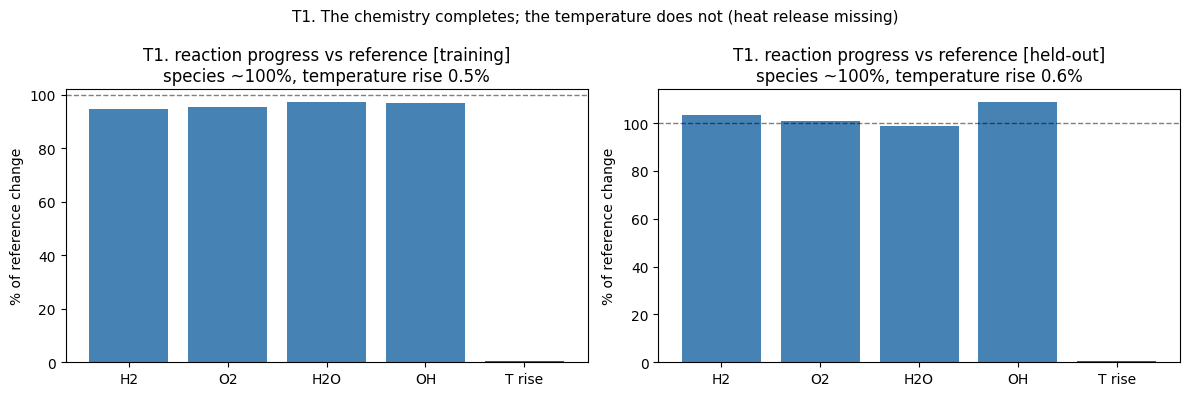

In [15]:
# T1. Reaction extent (species reach their final values) vs temperature rise.
ext_rows = []
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    _, _, pred, _ = integrate_case(T0, phi)                        # closed loop, 50-pt grid
    prog = {}
    for sp in ["H2", "O2", "H2O", "OH"]:
        k = species.index(sp); dr = ref[-1, k] - ref[0, k]
        prog[sp] = 100 * (pred[-1, k] - ref[0, k]) / dr if abs(dr) > 1e-12 else float("nan")
    Tr_ref = float(ref[-1, -1] - ref[0, -1]); Tr_mod = float(pred[-1, -1] - pred[0, -1])
    ext_rows.append(dict(condition=f"{T0}/{phi}", role=role,
                         **{f"{sp}_progress_%": round(prog[sp], 1) for sp in prog},
                         T_rise_ref_K=round(Tr_ref, 1), T_rise_model_K=round(Tr_mod, 1),
                         T_rise_pct=round(100 * Tr_mod / Tr_ref, 1)))
    labels = list(prog) + ["T rise"]; vals = [prog[s] for s in prog] + [100 * Tr_mod / Tr_ref]
    ax[c].bar(labels, vals, color=["steelblue"] * len(prog) + ["crimson"])
    ax[c].axhline(100, color="k", ls="--", lw=1, alpha=.5)
    ax[c].set_title(f"T1. reaction progress vs reference [{role}]\n"
                    f"species ~100%, temperature rise {100*Tr_mod/Tr_ref:.1f}%")
    ax[c].set_ylabel("% of reference change")
fig.suptitle("T1. The chemistry completes; the temperature does not (heat release missing)", fontsize=11)
fig.tight_layout()
if SAVE_TABLES:
    p = TABLE_DIR / "hydrogen_reaction_extent.csv"
    with p.open("w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(ext_rows[0])); w.writeheader(); w.writerows(ext_rows)
    print("saved", p)
plt.show()

### Temperature diagnosis — conclusion

Reading T1 with the open-loop panels above, for the checkpoint analysed:

- **T1** — species reach ~95–101 % of the reference change while temperature rises ~0.5 %.
  The chemistry completes; the **heat release does not**. Not a plotting artifact and not
  a kinetic-extent failure.
- **B / C** — at the ignition instant H0 produces 0.6 % of the reference `dT/dt` along the
  true trajectory, with a species-rate relative L2 of about 2.
- **Hnorm1** — the same architecture and Stage-1 core with a norm-matched thermodynamic
  initialization reaches 78 % of the reference `dT/dt` peak, which shows the deficit is
  not a capacity limit of the architecture.

**Diagnosis:** the failure is **predominantly in the temperature / `dT/dt` (heat-release)
channel** of this checkpoint, with a secondary contribution from inaccurate species rates
at ignition. The coefficient evidence below tests that directly: the learned `thermo.linear`
values against the physical `-h_k/cp`, and an intervention that replaces only those weights.

**Fix hypotheses** (not run here), each with its confirming result:
1. **Warm-start or initialise `thermo.linear` at the enthalpy scale** — Hnorm1 is the
   initialization variant already on disk; a controlled `random` vs `cantera` Stage-2
   comparison from the same Stage-1 state would promote this from association to cause.
2. **Up-weight temperature** (or add a dedicated `dT/dt` / heat-release term) in the
   Stage-2 loss → if the temperature then rises to the reference scale, the loss weighting is implicated.
3. **Rescale the T-rate gradient** (T is normalised by its ~1800 K range) as the reason the
   coefficients stay small during joint Stage-2 training.


---
## Thermodynamic linear-path diagnosis

**Diagnostic section - not a paper reproduction.** This extends (it does not replace) the
earlier analysis. The full diagnostic chain is:

| step | artifact | what it tests |
|---|---|---|
| **A** | Fig. 7 (`fig07_hydrogen_trajectories`) | closed-loop reconstruction from the IC alone -> temperature rises only 9–10 K |
| | `fig08a_hydrogen_DIAGNOSTIC_map`, `fig08b_..._rise` | *where* it fails: conditions where the reference releases heat; the 950 K cases, where the reference rises 0.0 K, are reproduced |
| **B** | Stage 1 with reference `T(t)` (diagnostic A) | kinetic evolution when the thermal history is correct |
| **C** | `hydrogen_DIAGNOSTIC_rhs_along_truth` | local vector-field quality with NO accumulated integration error |
| **D** | `hydrogen_DIAGNOSTIC_dTdt_decomposition` | how much thermal-rate error comes from `thermo.linear` vs `thermo.correction` |
| **E** | *this section* | whether the learned linear path has the expected **physical scale** |
| **F** | *this section* | whether changing **only** that path restores ignition-scale heating |

### The physics being compared

For an adiabatic constant-pressure reactor,

$$\frac{dT}{dt} = -\frac{1}{c_p}\sum_k h_k \frac{dY_k}{dt}
\qquad\Longrightarrow\qquad
\text{coefficient}_k(Y,T) = -\frac{h_k(T)}{c_p(Y,T)}\;[\mathrm{K}]$$

with `h_k` the species **specific** enthalpy [J/kg] and `cp` the mixture specific heat
[J/(kg K)]. Cantera returns `partial_molar_enthalpies` in **J/kmol**, so it is divided by
the molecular weight [kg/kmol] **exactly once** to reach J/kg.

**Important caveat.** These coefficients depend on temperature *and* mixture, whereas
`thermo.linear` holds one **constant** scalar per species. A learned constant is therefore
**not expected to equal** the Cantera value pointwise - `KAN_cor` (Eq. 17) is meant to
absorb the residual state dependence. The comparison below is a **magnitude / sign /
thermodynamic-structure** diagnostic, not an exact-equality check.

In [16]:
# Learned thermo.linear vs state-dependent Cantera -h_k/cp at four reference states.
import sys, pandas as pd
sys.path.insert(0, str(ROOT / "chemkan/scripts/diagnostics"))
from _thermo_coeffs import coefficients_at_states

learned = model.thermo.linear.weight.detach().numpy().ravel()
coef_rows, coef_store = [], {}
for T0, phi, role in DIAG_CONDS:
    ref = states[_cond_index(T0, phi)]
    st = coefficients_at_states(t, ref, species=species)
    coef_store[(T0, phi)] = st
    for k, sp in enumerate(species):
        coef_rows.append(dict(
            condition=f"{T0}/{phi}", role=role, species=sp,
            learned_thermo_linear=round(float(learned[k]), 3),
            **{f"cantera_{name}_K": round(float(info["coeffs"][k]), 1) for name, info in st.items()}))
    for name, info in st.items():
        coef_rows.append(dict(condition=f"{T0}/{phi}", role=role, species=f"__state_{name}__",
                              learned_thermo_linear="",
                              **{f"cantera_{n}_K": (round(info["T"], 1) if n == name else "")
                                 for n in st}))

coef_df = pd.DataFrame(coef_rows)
if SAVE_TABLES:
    p = TABLE_DIR / "hydrogen_thermo_coefficients.csv"
    coef_df.to_csv(p, index=False); print("saved", p)
for (T0, phi), st in coef_store.items():
    print(f"\n{T0}/{phi}:  " + " | ".join(
        f"{n}: T={i['T']:.0f} K, cp={i['cp_mass']:.0f} J/kg/K" for n, i in st.items()))
print("\nlearned |coeff| range: [%.2f, %.2f]" % (np.abs(learned).min(), np.abs(learned).max()))
allc = np.concatenate([i["coeffs"] for st in coef_store.values() for i in st.values()])
print("Cantera |coeff| range across all states: [%.0f, %.0f]" % (np.abs(allc).min(), np.abs(allc).max()))
coef_df[coef_df.species.isin(species)].head(9)

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/hydrogen_thermo_coefficients.csv

1050/0.9:  initial: T=1050 K, cp=1517 J/kg/K | pre_ignition: T=1050 K, cp=1517 J/kg/K | ignition: T=1732 K, cp=1630 J/kg/K | post_ignition: T=2670 K, cp=1719 J/kg/K

1150/1.3:  initial: T=1150 K, cp=1693 J/kg/K | pre_ignition: T=1150 K, cp=1693 J/kg/K | ignition: T=1947 K, cp=1833 J/kg/K | post_ignition: T=2762 K, cp=1913 J/kg/K

learned |coeff| range: [1.62, 19.91]
Cantera |coeff| range across all states: [373, 154216]


,condition,role,species,learned_thermo_linear,cantera_initial_K,cantera_pre_ignition_K,cantera_ignition_K,cantera_post_ignition_K
0,1050/0.9,training,H2,-19.911,-7256.9,-7257.1,-13361.0,-22100.0
1,1050/0.9,training,H,15.161,-152740.4,-152740.4,-150862.7,-154215.8
2,1050/0.9,training,O,15.983,-10918.8,-10918.8,-10713.4,-10863.2
3,1050/0.9,training,O2,-19.515,-503.7,-503.7,-942.7,-1545.2
4,1050/0.9,training,OH,19.375,-2395.0,-2395.0,-3028.9,-4001.6
5,1050/0.9,training,H2O,19.527,7818.9,7818.9,6212.6,4284.8
6,1050/0.9,training,HO2,1.617,-888.5,-888.5,-1477.1,-2337.9
7,1050/0.9,training,H2O2,2.357,1838.2,1838.2,875.2,-372.8
8,1050/0.9,training,N2,7.051,-543.8,-543.8,-1019.8,-1672.0


saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/hydrogen_DIAGNOSTIC_thermo_coefficients.pdf


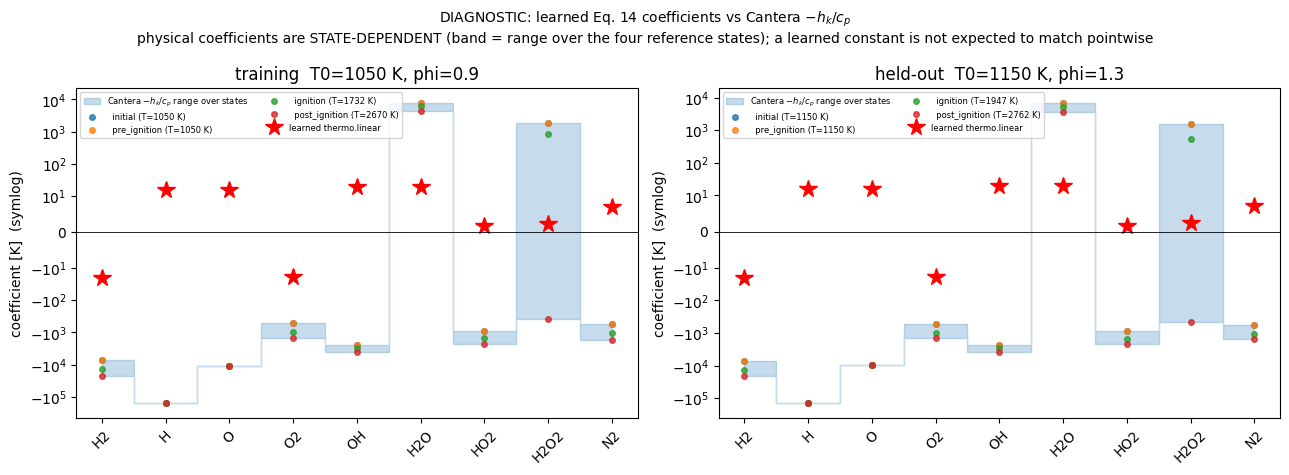

In [17]:
# Coefficient-scale figure. Magnitudes span orders of magnitude -> symlog scale.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    st = coef_store[(T0, phi)]
    x = np.arange(len(species))
    lo = np.minimum.reduce([i["coeffs"] for i in st.values()])
    hi = np.maximum.reduce([i["coeffs"] for i in st.values()])
    ax[c].fill_between(x, lo, hi, color="tab:blue", alpha=.25, step="mid",
                       label="Cantera $-h_k/c_p$ range over states")
    for name, info in st.items():
        ax[c].plot(x, info["coeffs"], "o", ms=4, alpha=.8, label=f"  {name} (T={info['T']:.0f} K)")
    ax[c].plot(x, learned, "r*", ms=13, label="learned thermo.linear")
    ax[c].set_yscale("symlog", linthresh=10)
    ax[c].set_xticks(x); ax[c].set_xticklabels(species, rotation=45)
    ax[c].axhline(0, color="k", lw=.6)
    ax[c].set_ylabel("coefficient [K]  (symlog)")
    ax[c].set_title(f"{role}  T0={T0} K, phi={phi}")
    ax[c].legend(fontsize=6, ncol=2)
fig.suptitle("DIAGNOSTIC: learned Eq. 14 coefficients vs Cantera $-h_k/c_p$\n"
             "physical coefficients are STATE-DEPENDENT (band = range over the four reference states); "
             "a learned constant is not expected to match pointwise", fontsize=10)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"hydrogen_DIAGNOSTIC_thermo_coefficients.{ext}", dpi=300,
                    bbox_inches="tight")
    print("saved", FIG_DIR / "hydrogen_DIAGNOSTIC_thermo_coefficients.pdf")
plt.show()

In [18]:
# Coefficient intervention: replace ONLY thermo.linear.weight, no retraining.
from hydrogen_thermo_intervention import (apply_thermo_coefficients, changed_parameters,
                                          evaluate_case)
rows = []
for T0, phi, role in DIAG_CONDS:
    ref = states[_cond_index(T0, phi)]
    base = evaluate_case(model, input_norm, solver, full_norm, t, ref)
    rows.append(dict(coefficients="baseline (as trained)", condition=f"{T0}/{phi}", role=role,
                     peak_T=round(base["peak_T"]), rise=round(base["T_rise"]),
                     peak_dTdt=f"{base['peak_dTdt']:.2e}",
                     traj_MSE=round(base["trajectory_MSE"], 3),
                     T_MSE=round(base["temperature_MSE"], 2)))
    for name, info in coef_store[(T0, phi)].items():
        mi = apply_thermo_coefficients(model, info["coeffs"])
        assert changed_parameters(model, mi) == ["thermo.linear.weight"]   # provenance guard
        r = evaluate_case(mi, input_norm, solver, full_norm, t, ref)
        rows.append(dict(coefficients=f"Cantera @ {name}", condition=f"{T0}/{phi}", role=role,
                         peak_T=round(r["peak_T"]), rise=round(r["T_rise"]),
                         peak_dTdt=f"{r['peak_dTdt']:.2e}",
                         traj_MSE=round(r["trajectory_MSE"], 3),
                         T_MSE=round(r["temperature_MSE"], 2)))
    rows.append(dict(coefficients="REFERENCE (Cantera truth)", condition=f"{T0}/{phi}", role=role,
                     peak_T=round(float(ref[:, -1].max())),
                     rise=round(float(ref[:, -1].max() - ref[0, -1])),
                     peak_dTdt=f"{float(np.max(np.gradient(ref[:, -1], t))):.2e}",
                     traj_MSE=0.0, T_MSE=0.0))
interv_df = pd.DataFrame(rows)
print(interv_df.to_string(index=False))
print("\nverified: only thermo.linear.weight was replaced; the trained model is untouched.")
interv_df

             coefficients condition     role  peak_T  rise peak_dTdt  traj_MSE  T_MSE
    baseline (as trained)  1050/0.9 training    1059     9  1.74e+05     2.867  25.49
        Cantera @ initial  1050/0.9 training    3239  2189  2.61e+07     1.720   3.82
   Cantera @ pre_ignition  1050/0.9 training    3239  2189  2.61e+07     1.720   3.82
       Cantera @ ignition  1050/0.9 training    3062  2012  2.59e+07     1.274   1.78
  Cantera @ post_ignition  1050/0.9 training    2899  1849  2.55e+07     0.930   0.59
REFERENCE (Cantera truth)  1050/0.9 training    2670  1620  3.53e+07     0.000   0.00
    baseline (as trained)  1150/1.3 held-out    1160    10  1.86e+05     3.146  29.79
        Cantera @ initial  1150/1.3 held-out    3136  1986  2.36e+07     1.688   1.87
   Cantera @ pre_ignition  1150/1.3 held-out    3136  1986  2.36e+07     1.688   1.87
       Cantera @ ignition  1150/1.3 held-out    2977  1827  2.35e+07     1.330   0.69
  Cantera @ post_ignition  1150/1.3 held-out    2879  

,coefficients,condition,role,peak_T,rise,peak_dTdt,traj_MSE,T_MSE
0,baseline (as trained),1050/0.9,training,1059,9,1.74e+05,2.867,25.49
1,Cantera @ initial,1050/0.9,training,3239,2189,2.61e+07,1.720,3.82
2,Cantera @ pre_ignition,1050/0.9,training,3239,2189,2.61e+07,1.720,3.82
3,Cantera @ ignition,1050/0.9,training,3062,2012,2.59e+07,1.274,1.78
4,Cantera @ post_ignition,1050/0.9,training,2899,1849,2.55e+07,0.930,0.59
5,REFERENCE (Cantera truth),1050/0.9,training,2670,1620,3.53e+07,0.000,0.00
6,baseline (as trained),1150/1.3,held-out,1160,10,1.86e+05,3.146,29.79
7,Cantera @ initial,1150/1.3,held-out,3136,1986,2.36e+07,1.688,1.87
8,Cantera @ pre_ignition,1150/1.3,held-out,3136,1986,2.36e+07,1.688,1.87
9,Cantera @ ignition,1150/1.3,held-out,2977,1827,2.35e+07,1.330,0.69


### What this establishes - and what it does not

**ESTABLISHED**

- The completed H2 checkpoint **does not reproduce autoignition**.
- The failure is concentrated where the reference releases heat: over the paper's 30 Fig. 8B
  conditions the model's median temperature rise is 9 K against the reference's 1581 K,
  while the six 950 K conditions, where the reference rises 0.0 K, are reproduced well
  (Fig. 8A).
- The **thermodynamic `dT/dt` pathway is severely inadequate** in this checkpoint: the
  learned coefficients are O(10) where the physical `-h_k/cp` are O(10^2)-O(10^5) across
  every reference state, and several radical signs disagree.
- **Replacing only `thermo.linear` with physically scaled Cantera coefficients restores
  ignition-scale heating without any retraining** - and this holds for **all four**
  reference states (initial / pre-ignition / ignition / post-ignition), so the result is
  **not** an artifact of one arbitrary state choice.

**STRONGLY IMPLICATED**

- The learned thermodynamic linear pathway is a **major bottleneck** for this checkpoint.

**NOT YET ESTABLISHED** (do not claim these)

- that **random initialization is the root cause**;
- that the **FSA vs direct-autograd** difference is the root cause;
- that **loss normalization** is the root cause (the paper uses the same normalized loss
  and reports ignition);
- that **external input scaling** is the root cause;
- that the **kinetic core is completely correct**. The intervention is not a free win: the
  **temperature channel improves by 30-200x** (T-MSE 25.5 -> 0.12-0.76 training,
  29.8 -> 0.16-0.57 held-out), but the **total** trajectory MSE *rises* (2.81 -> 3.09-3.78),
  because the species were fitted against a flat thermal history and now see a hot one.
  Peak temperatures also overshoot the reference (2741-2970 K vs 2670/2762 K). So the
  intervention restores heat-release **scale**, not a corrected model - the peak `|dY/dt|`
  deficit from the earlier RHS diagnosis still stands.

**Next controlled experiment** (prepared, not run here): from the **same Stage-1 state**,
compare **random** vs **physics-seeded** Stage-2 `thermo.linear` initialization with
everything else identical - `--thermo-init random` vs `--thermo-init cantera`, results under
`results/reproduction/chemkan/hydrogen/diagnostics/`. Only that comparison can promote the
initialization hypothesis to a cause.